# PDM Score — Warmup Two-Stage Evaluation

Interactive reproduction of `run_pdm_score.py` on the `warmup_two_stage` split.

**Pipeline:**
1. Config — paths and components
2. Load scene filter from config YAML and build `SceneLoader`
3. Stage 1 — score 16 original scenes with reactive traffic
4. Stage 2 — score ~240 synthetic follow-up scenes with reactive traffic
5. `SceneAggregator` — compute two-frame extended comfort and Gaussian weights
6. `compute_final_scores` — multiply weighted metrics → per-token score
7. `calculate_individual_mapping_scores` — group-level Stage 1 × Stage 2 score
8. Save results and visualize

## 1. Config

In [26]:
import os
from pathlib import Path

NAVSIM_ROOT         = Path("/home/weiyu/workspace/navsim")
OPENSCENE_DATA_ROOT = NAVSIM_ROOT / "dataset"
NAVSIM_EXP_ROOT     = NAVSIM_ROOT / "exp"

# warmup_two_stage uses data_split=test for navsim_logs;
# sensor data (both original and synthetic scenes) lives under warmup_two_stage/
NAVSIM_LOG_PATH       = OPENSCENE_DATA_ROOT / "navsim_logs" / "test"
ORIGINAL_SENSOR_PATH  = OPENSCENE_DATA_ROOT / "warmup_two_stage" / "sensor_blobs"
SYNTHETIC_SENSOR_PATH = OPENSCENE_DATA_ROOT / "warmup_two_stage" / "sensor_blobs"
SYNTHETIC_SCENES_PATH = OPENSCENE_DATA_ROOT / "warmup_two_stage" / "synthetic_scene_pickles"
METRIC_CACHE_PATH     = NAVSIM_EXP_ROOT / "metric_cache"
OUTPUT_DIR            = NAVSIM_EXP_ROOT / "pdm_score_warmup_two_stage_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Log path          : {NAVSIM_LOG_PATH}  (exists: {NAVSIM_LOG_PATH.exists()})")
print(f"Original sensors  : {ORIGINAL_SENSOR_PATH}  (exists: {ORIGINAL_SENSOR_PATH.exists()})")
print(f"Synthetic sensors : {SYNTHETIC_SENSOR_PATH}  (exists: {SYNTHETIC_SENSOR_PATH.exists()})")
print(f"Synthetic scenes  : {SYNTHETIC_SCENES_PATH}  (exists: {SYNTHETIC_SCENES_PATH.exists()})")
print(f"Metric cache      : {METRIC_CACHE_PATH}  (exists: {METRIC_CACHE_PATH.exists()})")
print(f"Output dir        : {OUTPUT_DIR}")

Log path          : /home/weiyu/workspace/navsim/dataset/navsim_logs/test  (exists: True)
Original sensors  : /home/weiyu/workspace/navsim/dataset/warmup_two_stage/sensor_blobs  (exists: True)
Synthetic sensors : /home/weiyu/workspace/navsim/dataset/warmup_two_stage/sensor_blobs  (exists: True)
Synthetic scenes  : /home/weiyu/workspace/navsim/dataset/warmup_two_stage/synthetic_scene_pickles  (exists: True)
Metric cache      : /home/weiyu/workspace/navsim/exp/metric_cache  (exists: True)
Output dir        : /home/weiyu/workspace/navsim/exp/pdm_score_warmup_two_stage_notebook


## 2. Instantiate Simulator, Scorer, Agent, Traffic Policy

In [27]:
from nuplan.planning.simulation.trajectory.trajectory_sampling import TrajectorySampling

from navsim.agents.constant_velocity_agent import ConstantVelocityAgent
from navsim.planning.simulation.planner.pdm_planner.simulation.pdm_simulator import PDMSimulator
from navsim.planning.simulation.planner.pdm_planner.scoring.pdm_scorer import PDMScorer, PDMScorerConfig
from navsim.traffic_agents_policies.navsim_IDM_traffic_agents import NavsimIDMTrafficAgents
from navsim.planning.simulation.observation.navsim_idm_agents import NavsimIDMAgents

proposal_sampling = TrajectorySampling(num_poses=40, interval_length=0.1)

simulator = PDMSimulator(proposal_sampling=proposal_sampling)

scorer = PDMScorer(
    proposal_sampling=proposal_sampling,
    config=PDMScorerConfig(
        progress_weight=5.0,
        ttc_weight=5.0,
        lane_keeping_weight=2.0,
        history_comfort_weight=2.0,
        two_frame_extended_comfort_weight=2.0,
    ),
)

agent = ConstantVelocityAgent()
agent.initialize()

# Both stages use reactive (IDM) traffic agents
idm_obs = NavsimIDMAgents(
    target_velocity=10, min_gap_to_lead_agent=1.0, headway_time=1.5,
    accel_max=1.0, decel_max=2.0, open_loop_detections_types=[],
    minimum_path_length=20, planned_trajectory_samples=None,
    planned_trajectory_sample_interval=None, radius=100,
    add_open_loop_parked_vehicles=True, idm_snap_threshold=3.0,
)
traffic_agents_policy = NavsimIDMTrafficAgents(
    future_trajectory_sampling=proposal_sampling, idm_agents_observation=idm_obs
)

print(f"Agent         : {agent.__class__.__name__}")
print(f"Traffic policy: {traffic_agents_policy.__class__.__name__} (reactive IDM)")
print(f"Proposal steps: {proposal_sampling.num_poses} x {proposal_sampling.interval_length}s = {proposal_sampling.num_poses * proposal_sampling.interval_length:.1f}s horizon")

Agent         : ConstantVelocityAgent
Traffic policy: NavsimIDMTrafficAgents (reactive IDM)
Proposal steps: 40 x 0.1s = 4.0s horizon


## 3. Load Scene Filter from Config and Build SceneLoader

In [28]:
from omegaconf import OmegaConf

from navsim.common.dataclasses import SceneFilter, SensorConfig
from navsim.common.dataloader import MetricCacheLoader, SceneLoader

SPLIT_CFG_PATH  = NAVSIM_ROOT / "navsim/planning/script/config/common/train_test_split/warmup_two_stage.yaml"
FILTER_CFG_PATH = NAVSIM_ROOT / "navsim/planning/script/config/common/train_test_split/scene_filter/warmup_two_stage.yaml"

split_cfg  = OmegaConf.load(SPLIT_CFG_PATH)   # contains reactive_all_mapping
filter_cfg = OmegaConf.load(FILTER_CFG_PATH)  # contains token lists and frame settings

scene_filter = SceneFilter(
    num_history_frames=filter_cfg.num_history_frames,
    num_future_frames=filter_cfg.num_future_frames,
    frame_interval=filter_cfg.frame_interval,
    has_route=filter_cfg.has_route,
    include_synthetic_scenes=filter_cfg.include_synthetic_scenes,
    log_names=list(filter_cfg.log_names),
    tokens=list(filter_cfg.tokens),
    reactive_synthetic_initial_tokens=list(filter_cfg.reactive_synthetic_initial_tokens),
)

scene_loader = SceneLoader(
    original_sensor_path=ORIGINAL_SENSOR_PATH,
    synthetic_sensor_path=SYNTHETIC_SENSOR_PATH,
    data_path=NAVSIM_LOG_PATH,
    synthetic_scenes_path=SYNTHETIC_SCENES_PATH,
    scene_filter=scene_filter,
    sensor_config=agent.get_sensor_config(),
)

metric_cache_loader = MetricCacheLoader(METRIC_CACHE_PATH)

tokens_stage_one = scene_loader.tokens_stage_one
tokens_stage_two = scene_loader.reactive_tokens_stage_two

stage_one_to_eval = list(set(tokens_stage_one) & set(metric_cache_loader.tokens))
stage_two_to_eval = list(set(tokens_stage_two) & set(metric_cache_loader.tokens))

print(f"Stage 1 original tokens  : {len(tokens_stage_one)} total, {len(stage_one_to_eval)} with metric cache")
print(f"Stage 2 synthetic tokens : {len(tokens_stage_two)} total, {len(stage_two_to_eval)} with metric cache")
print(f"Metric cache entries     : {len(metric_cache_loader.tokens)}")

Loading synthetic scenes: 100%|██████████| 204/204 [00:01<00:00, 175.74it/s]

Stage 1 original tokens  : 16 total, 16 with metric cache
Stage 2 synthetic tokens : 204 total, 204 with metric cache
Metric cache entries     : 220


## 4. Stage 1 — Score Original Scenes

Runs the agent on the 16 real scenes with reactive traffic.
Records `ego_simulated_states` so the SceneAggregator can compute two-frame extended comfort across the Stage 1 → Stage 2 boundary.

In [29]:
import traceback
import pandas as pd
from nuplan.common.actor_state.state_representation import StateSE2
from nuplan.common.geometry.convert import relative_to_absolute_poses

from navsim.common.dataclasses import PDMResults
from navsim.evaluate.pdm_score import pdm_score

stage_one_results = []

for idx, token in enumerate(stage_one_to_eval):
    print(f"[Stage 1  {idx+1}/{len(stage_one_to_eval)}] token={token}")
    try:
        metric_cache = metric_cache_loader.get_from_token(token)
        agent_input  = scene_loader.get_agent_input_from_token(token)
        trajectory   = agent.compute_trajectory(agent_input) if not agent.requires_scene \
                       else agent.compute_trajectory(agent_input, scene_loader.get_scene_from_token(token))

        score_row, ego_simulated_states = pdm_score(
            metric_cache=metric_cache,
            model_trajectory=trajectory,
            future_sampling=simulator.proposal_sampling,
            simulator=simulator,
            scorer=scorer,
            traffic_agents_policy=traffic_agents_policy,
        )

        end_pose         = StateSE2(x=trajectory.poses[-1, 0], y=trajectory.poses[-1, 1], heading=trajectory.poses[-1, 2])
        absolute_endpoint = relative_to_absolute_poses(metric_cache.ego_state.rear_axle, [end_pose])[0]

        score_row["valid"]               = True
        score_row["log_name"]            = metric_cache.log_name
        score_row["frame_type"]          = metric_cache.scene_type
        score_row["start_time"]          = metric_cache.timepoint.time_s
        score_row["endpoint_x"]          = absolute_endpoint.x
        score_row["endpoint_y"]          = absolute_endpoint.y
        score_row["start_point_x"]       = metric_cache.ego_state.rear_axle.x
        score_row["start_point_y"]       = metric_cache.ego_state.rear_axle.y
        score_row["ego_simulated_states"] = [ego_simulated_states]

    except Exception:
        print(f"  WARNING: agent failed for token {token}")
        traceback.print_exc()
        score_row = pd.DataFrame([PDMResults.get_empty_results()])
        score_row["valid"] = False

    score_row["token"] = token
    stage_one_results.append(score_row)

stage_one_df = pd.concat(stage_one_results, ignore_index=True)
print(f"\nStage 1 done. Shape: {stage_one_df.shape}  |  Success: {stage_one_df['valid'].sum()}")

[Stage 1  1/16] token=ae472d675a965aca
[Stage 1  2/16] token=68097b10029d5fe1
[Stage 1  3/16] token=d01fec804cd45644
[Stage 1  4/16] token=f3ca2707d87a586b
[Stage 1  5/16] token=f6b9867069845fd2
[Stage 1  6/16] token=2382542e05f253df
[Stage 1  7/16] token=19e90f2757b25f38
[Stage 1  8/16] token=4cac9f6cd85a5b47
[Stage 1  9/16] token=c1839a3333695317
[Stage 1  10/16] token=0dc54a8c8203567b
[Stage 1  11/16] token=13310ca9a7715154
[Stage 1  12/16] token=f14e7ed78b5d55b4
[Stage 1  13/16] token=3c542be991515ccd
[Stage 1  14/16] token=5f53001e7e2d5347
[Stage 1  15/16] token=ed3db88f99a05a6c
[Stage 1  16/16] token=c054f473288d5515

Stage 1 done. Shape: (16, 22)  |  Success: 16


## 5. Stage 2 — Score Synthetic Follow-up Scenes

Runs the agent on ~240 synthetic scenes. Each starts from a different lateral/speed offset.
The SceneAggregator will later weight each by a Gaussian kernel based on its distance to the Stage 1 endpoint.

In [30]:
stage_two_results = []

for idx, token in enumerate(stage_two_to_eval):
    print(f"[Stage 2  {idx+1}/{len(stage_two_to_eval)}] token={token}")
    try:
        metric_cache = metric_cache_loader.get_from_token(token)
        agent_input  = scene_loader.get_agent_input_from_token(token)
        trajectory   = agent.compute_trajectory(agent_input) if not agent.requires_scene \
                       else agent.compute_trajectory(agent_input, scene_loader.get_scene_from_token(token))

        score_row, ego_simulated_states = pdm_score(
            metric_cache=metric_cache,
            model_trajectory=trajectory,
            future_sampling=simulator.proposal_sampling,
            simulator=simulator,
            scorer=scorer,
            traffic_agents_policy=traffic_agents_policy,
        )

        end_pose         = StateSE2(x=trajectory.poses[-1, 0], y=trajectory.poses[-1, 1], heading=trajectory.poses[-1, 2])
        absolute_endpoint = relative_to_absolute_poses(metric_cache.ego_state.rear_axle, [end_pose])[0]

        score_row["valid"]               = True
        score_row["log_name"]            = metric_cache.log_name
        score_row["frame_type"]          = metric_cache.scene_type
        score_row["start_time"]          = metric_cache.timepoint.time_s
        score_row["endpoint_x"]          = absolute_endpoint.x
        score_row["endpoint_y"]          = absolute_endpoint.y
        score_row["start_point_x"]       = metric_cache.ego_state.rear_axle.x
        score_row["start_point_y"]       = metric_cache.ego_state.rear_axle.y
        score_row["ego_simulated_states"] = [ego_simulated_states]

    except Exception:
        print(f"  WARNING: agent failed for token {token}")
        traceback.print_exc()
        score_row = pd.DataFrame([PDMResults.get_empty_results()])
        score_row["valid"] = False

    score_row["token"] = token
    stage_two_results.append(score_row)

stage_two_df = pd.concat(stage_two_results, ignore_index=True)
print(f"\nStage 2 done. Shape: {stage_two_df.shape}  |  Success: {stage_two_df['valid'].sum()}")

[Stage 2  1/204] token=188fef8a871d3bb74
[Stage 2  2/204] token=6808c5efa6976fe37
[Stage 2  3/204] token=be4d95422b6b6e212
[Stage 2  4/204] token=8f3bf4b1cb4be05f8
[Stage 2  5/204] token=875f6c89666fde397
[Stage 2  6/204] token=a31ca4af2bc4ff90a
[Stage 2  7/204] token=2df81c34dac0b3f5c
[Stage 2  8/204] token=4533792bbf9b2478b
[Stage 2  9/204] token=6f8794f5f301202d0
[Stage 2  10/204] token=b545597d491f4a96e
[Stage 2  11/204] token=f0ec163fc911ff8bb
[Stage 2  12/204] token=ea96a137518d58ac9
[Stage 2  13/204] token=3c8afefbaf08142c1
[Stage 2  14/204] token=38d50c91468fbe6e5
[Stage 2  15/204] token=bc730296c22859127
[Stage 2  16/204] token=71afcb9b1ac436e14
[Stage 2  17/204] token=5922fad17f2f5e59f
[Stage 2  18/204] token=801d1b42c0409656b
[Stage 2  19/204] token=6d8d91ad290f124b2
[Stage 2  20/204] token=ebe3f434bfee258dc
[Stage 2  21/204] token=8aea1806b6e406159
[Stage 2  22/204] token=fc3f449099625878e
[Stage 2  23/204] token=c909e005442d28a9c
[Stage 2  24/204] token=07a36d3f2100bc352
[

## 6. Combine Stage 1 + Stage 2 Results

In [31]:
pdm_score_df = pd.concat([stage_one_df, stage_two_df], ignore_index=True)
print(f"Combined df shape : {pdm_score_df.shape}")
print(f"Stage 1 rows      : {len(stage_one_df)}")
print(f"Stage 2 rows      : {len(stage_two_df)}")

Combined df shape : (220, 22)
Stage 1 rows      : 16
Stage 2 rows      : 204


## 7. Load Two-Stage Mappings

`reactive_all_mapping` from `warmup_two_stage.yaml` encodes which Stage 2 synthetic scenes
correspond to each Stage 1 original scene pair `(orig_token, prev_token)`.

In [32]:
# Build all_mappings: {(orig_token, prev_token): [(s2_now_0, s2_prev_0), ...]}
all_mappings = {}
for orig_token, prev_token, two_stage_pairs in split_cfg.reactive_all_mapping:
    all_mappings[(orig_token, prev_token)] = [tuple(pair) for pair in two_stage_pairs]

print(f"Two-stage mapping groups : {len(all_mappings)}")
for (orig, prev), pairs in list(all_mappings.items())[:2]:
    print(f"  ({orig[:8]}…, {prev[:8]}…) → {len(pairs)} synthetic pairs")

Two-stage mapping groups : 8
  (4cac9f6c…, 2382542e…) → 10 synthetic pairs
  (c054f473…, 68097b10…) → 15 synthetic pairs


## 8. SceneAggregator — Two-Frame Comfort and Gaussian Weights

For each mapping group the `SceneAggregator`:
- computes **two-frame extended comfort** by comparing the simulated trajectory at the Stage 1 / Stage 2 boundary
- assigns a **Gaussian weight** `exp(-d² / 2σ²)` (σ²=0.1) to each Stage 2 scene based on how close its starting position is to the agent's actual Stage 1 endpoint

In [33]:
import numpy as np
from navsim.planning.simulation.planner.pdm_planner.scoring.scene_aggregator import SceneAggregator


def create_scene_aggregators(all_mappings, full_score_df, proposal_sampling):
    full_score_df["two_frame_extended_comfort"] = np.nan
    full_score_df["weight"] = np.nan
    full_score_df = full_score_df.set_index("token")

    all_updates = []
    for (now_frame, previous_frame), second_stage in all_mappings.items():
        aggregator = SceneAggregator(
            now_frame=now_frame,
            previous_frame=previous_frame,
            second_stage=second_stage,
            score_df=full_score_df,
            proposal_sampling=proposal_sampling,
        )
        all_updates.append(aggregator.aggregate_scores())

    all_updates_df = pd.concat(all_updates, ignore_index=True).set_index("token")
    full_score_df.update(all_updates_df)
    full_score_df.reset_index(inplace=True)
    return full_score_df.drop(columns=["ego_simulated_states"])


pdm_score_df = create_scene_aggregators(all_mappings, pdm_score_df, proposal_sampling)

nan_comfort = pdm_score_df["two_frame_extended_comfort"].isna().sum()
print(f"Tokens with two_frame_extended_comfort : {(~pdm_score_df['two_frame_extended_comfort'].isna()).sum()}")
print(f"Tokens missing two_frame_extended_comfort: {nan_comfort}")

Tokens with two_frame_extended_comfort : 220
Tokens missing two_frame_extended_comfort: 0


## 9. Compute Final Per-Token Scores

Injects `two_frame_extended_comfort` into the weighted metric vector, then:

```
score = multiplicative_metrics_prod × (Σ weight_i × metric_i) / Σ weight_i
```

In [34]:
from navsim.planning.simulation.planner.pdm_planner.utils.pdm_enums import WeightedMetricIndex


def compute_final_scores(pdm_score_df):
    df = pdm_score_df.reset_index(drop=True)
    assert not df["two_frame_extended_comfort"].isna().any(), \
        "NaN in two_frame_extended_comfort — check SceneAggregator completeness."

    two_frame_scores       = df["two_frame_extended_comfort"].to_numpy()
    weighted_metrics       = np.stack(df["weighted_metrics"].to_numpy())
    weighted_metrics_array = np.stack(df["weighted_metrics_array"].to_numpy())

    two_frame_idx = WeightedMetricIndex.TWO_FRAME_EXTENDED_COMFORT
    weighted_metrics[:, two_frame_idx] = two_frame_scores

    weighted_sum  = (weighted_metrics * weighted_metrics_array).sum(axis=1)
    total_weight  = weighted_metrics_array.sum(axis=1)
    assert np.all(total_weight > 0)

    df["score"] = df["multiplicative_metrics_prod"].to_numpy() * (weighted_sum / total_weight)
    df.drop(columns=["weighted_metrics", "weighted_metrics_array", "multiplicative_metrics_prod"], inplace=True)
    return df


pdm_score_df = compute_final_scores(pdm_score_df)
print(f"Final df shape : {pdm_score_df.shape}")
pdm_score_df[["token", "frame_type", "weight", "two_frame_extended_comfort", "score"]].head(6)

Final df shape : (220, 21)


,token,frame_type,weight,two_frame_extended_comfort,score
0,ae472d675a965aca,0,1.0,1.0,0.821328
1,68097b10029d5fe1,0,1.0,1.0,0.859886
2,d01fec804cd45644,0,1.0,1.0,0.000000
3,f3ca2707d87a586b,0,1.0,1.0,0.000000
4,f6b9867069845fd2,0,1.0,0.0,0.875000
5,2382542e05f253df,0,1.0,1.0,0.963204


## 10. Group-Level Scoring — Stage 1 × Stage 2

For each mapping group (orig_token, prev_token):
```
group_score = (stage1_score_orig × weighted_avg(stage2_scores_orig)
             + stage1_score_prev × weighted_avg(stage2_scores_prev)) / 2
```
Final combined score = mean over all groups.

In [35]:
from dataclasses import fields
from navsim.common.enums import SceneFrameType

score_cols = [
    c for c in pdm_score_df.columns
    if (any(f.name in c for f in fields(PDMResults)) or c in ("two_frame_extended_comfort", "score"))
    and c != "pdm_score"
]


def calculate_weighted_average_score(df):
    cols = [c for c in df.columns if c not in {"weight", "token"}]
    if df.empty:
        return pd.Series([np.nan] * len(cols), index=cols)
    w = df["weight"].to_numpy()
    total = w.sum()
    if total == 0:
        return pd.Series([np.nan] * len(cols), index=cols)
    return pd.Series((df[cols].to_numpy() * w[:, None]).sum(axis=0) / total, index=cols)


def calculate_individual_mapping_scores(pdm_score_df, all_mappings):
    all_group, stage1_rows, stage2_rows = [], [], []

    for (orig_token, prev_token), second_stage_pairs in all_mappings.items():
        first_tokens  = [p[0] for p in second_stage_pairs if len(p) > 0]
        second_tokens = [p[1] for p in second_stage_pairs if len(p) > 1]

        g1_s1 = calculate_weighted_average_score(pdm_score_df[pdm_score_df["token"] == orig_token])
        g1_s2 = calculate_weighted_average_score(pdm_score_df[pdm_score_df["token"].isin(first_tokens)])
        g2_s1 = calculate_weighted_average_score(pdm_score_df[pdm_score_df["token"] == prev_token])
        g2_s2 = calculate_weighted_average_score(pdm_score_df[pdm_score_df["token"].isin(second_tokens)])

        stage1_rows += [g1_s1, g2_s1]
        stage2_rows += [g1_s2, g2_s2]
        all_group.append((g1_s1 * g1_s2 + g2_s1 * g2_s2) / 2)

    return (
        pd.DataFrame(all_group).mean(),
        pd.DataFrame(stage1_rows).mean(),
        pd.DataFrame(stage2_rows).mean(),
    )


score_df_with_weight = pdm_score_df[score_cols + ["token", "weight"]]
pcl_combined, pcl_stage1, pcl_stage2 = calculate_individual_mapping_scores(score_df_with_weight, all_mappings)

print(f"Stage 1 avg score  : {pcl_stage1['score']:.4f}")
print(f"Stage 2 avg score  : {pcl_stage2['score']:.4f}")
print(f"Combined PCL score : {pcl_combined['score']:.4f}")

Stage 1 avg score  : 0.4525
Stage 2 avg score  : 0.3341
Combined PCL score : 0.1854


## 11. Summary and Save

In [36]:
from datetime import datetime

# Save a snapshot before column-splitting — used in visualization cells below
viz_df = pdm_score_df.copy()

# Split per-token results into stage_one / stage_two columns
stage_one_mask = pdm_score_df["frame_type"] == SceneFrameType.ORIGINAL
stage_two_mask = pdm_score_df["frame_type"] == SceneFrameType.SYNTHETIC

for col in score_cols:
    pdm_score_df.loc[stage_one_mask, f"{col}_stage_one"] = pdm_score_df.loc[stage_one_mask, col]
    pdm_score_df.loc[stage_two_mask, f"{col}_stage_two"] = pdm_score_df.loc[stage_two_mask, col]

pdm_score_df.drop(columns=score_cols, inplace=True)
pdm_score_df["score"] = pdm_score_df.get("score_stage_one", pd.Series(dtype=float)).combine_first(
    pdm_score_df.get("score_stage_two", pd.Series(dtype=float))
)

stage1_cols = [f"{c}_stage_one" for c in score_cols if c != "score"]
stage2_cols = [f"{c}_stage_two" for c in score_cols if c != "score"]
output_cols = ["token", "valid"] + stage1_cols + stage2_cols + ["score"]
output_cols = [c for c in output_cols if c in pdm_score_df.columns]

# Append summary rows
def make_summary_row(label, series, col_map):
    row = {c: np.nan for c in output_cols}
    row["token"], row["valid"] = label, True
    for orig_col, dest_col in col_map.items():
        if orig_col in series.index and dest_col in row:
            row[dest_col] = series[orig_col]
    return row

summary = pd.DataFrame([
    make_summary_row("extended_pdm_score_stage_one",  pcl_stage1,   {c: f"{c}_stage_one" for c in score_cols}),
    make_summary_row("extended_pdm_score_stage_two",  pcl_stage2,   {c: f"{c}_stage_two" for c in score_cols}),
    make_summary_row("extended_pdm_score_combined",   pcl_combined, {**{c: f"{c}_stage_one" for c in score_cols},
                                                                        **{c: f"{c}_stage_two" for c in score_cols}}),
])

final_df = pd.concat([pdm_score_df[output_cols], summary], ignore_index=True)

timestamp = datetime.now().strftime("%Y.%m.%d.%H.%M.%S")
csv_path  = OUTPUT_DIR / f"{timestamp}.csv"
final_df.to_csv(csv_path, index=False)

print(f"Saved to : {csv_path}")
print()
print(final_df[final_df["token"].str.startswith("extended")][["token", "score"]].to_string(index=False))

Saved to : /home/weiyu/workspace/navsim/exp/pdm_score_warmup_two_stage_notebook/2026.05.05.11.51.55.csv

                       token  score
extended_pdm_score_stage_one    NaN
extended_pdm_score_stage_two    NaN
 extended_pdm_score_combined    NaN


## 12. Visualization Setup — Scene Loader with Cameras

`ConstantVelocityAgent` uses no sensors, so we create a separate `SceneLoader` that loads
all 8 cameras at the current frame only (`include=[num_history_frames-1]`).
This is used for all scene/camera/trajectory visualizations below.

In [37]:
import os
from navsim.common.dataclasses import SensorConfig

# Ensure maps root is set so BEV rendering can load map polygons
os.environ.setdefault("NUPLAN_MAPS_ROOT", str(OPENSCENE_DATA_ROOT / "maps"))

cur_frame_idx = scene_filter.num_history_frames - 1

# Stage 1 original scenes: sensor_blobs/test is not part of the warmup download,
# so we load no cameras — BEV + annotations still work (they come from the log pickle).
s1_viz_loader = SceneLoader(
    original_sensor_path=ORIGINAL_SENSOR_PATH,
    synthetic_sensor_path=SYNTHETIC_SENSOR_PATH,
    data_path=NAVSIM_LOG_PATH,
    synthetic_scenes_path=SYNTHETIC_SCENES_PATH,
    scene_filter=scene_filter,
    sensor_config=SensorConfig.build_no_sensors(),
)

# Stage 2 synthetic scenes: warmup_two_stage/sensor_blobs/ contains the synthetic images.
s2_viz_loader = SceneLoader(
    original_sensor_path=ORIGINAL_SENSOR_PATH,
    synthetic_sensor_path=SYNTHETIC_SENSOR_PATH,
    data_path=NAVSIM_LOG_PATH,
    synthetic_scenes_path=SYNTHETIC_SCENES_PATH,
    scene_filter=scene_filter,
    sensor_config=SensorConfig.build_all_sensors(include=[cur_frame_idx]),
)

print("s1_viz_loader : no cameras (sensor_blobs/test not in warmup download) — BEV/annotations only")
print("s2_viz_loader : cameras at current frame from warmup_two_stage/sensor_blobs/")

Loading synthetic scenes: 100%|██████████| 204/204 [00:01<00:00, 170.42it/s]

s1_viz_loader : no cameras (sensor_blobs/test not in warmup download) — BEV/annotations only
s2_viz_loader : cameras at current frame from warmup_two_stage/sensor_blobs/


## 13. Stage 1 — Per-Scene: BEV, Trajectory, Metric Scores

For each of the 16 original Stage 1 scenes (camera images require sensor_blobs/test which is not
part of the warmup download, so we show BEV only):

- **Left**: BEV with map, surrounding agents (bounding boxes), **agent trajectory** (red) vs **ground-truth trajectory** (green), endpoint ★
- **Right**: Per-metric score bar chart; bars turn red when score < 0.8

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


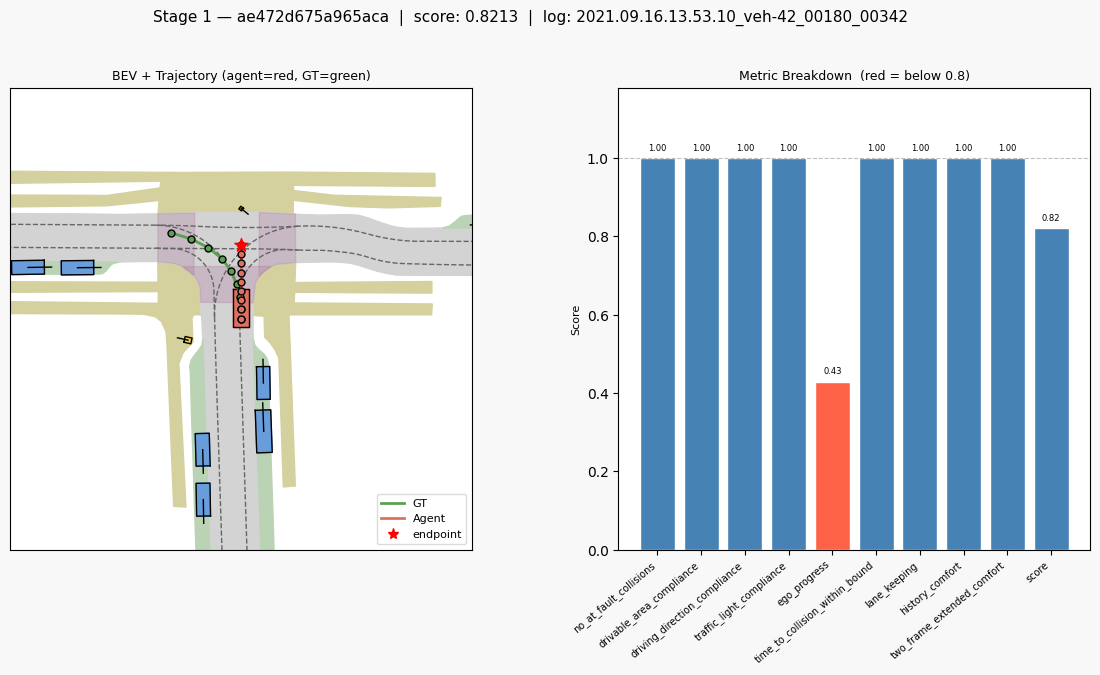

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


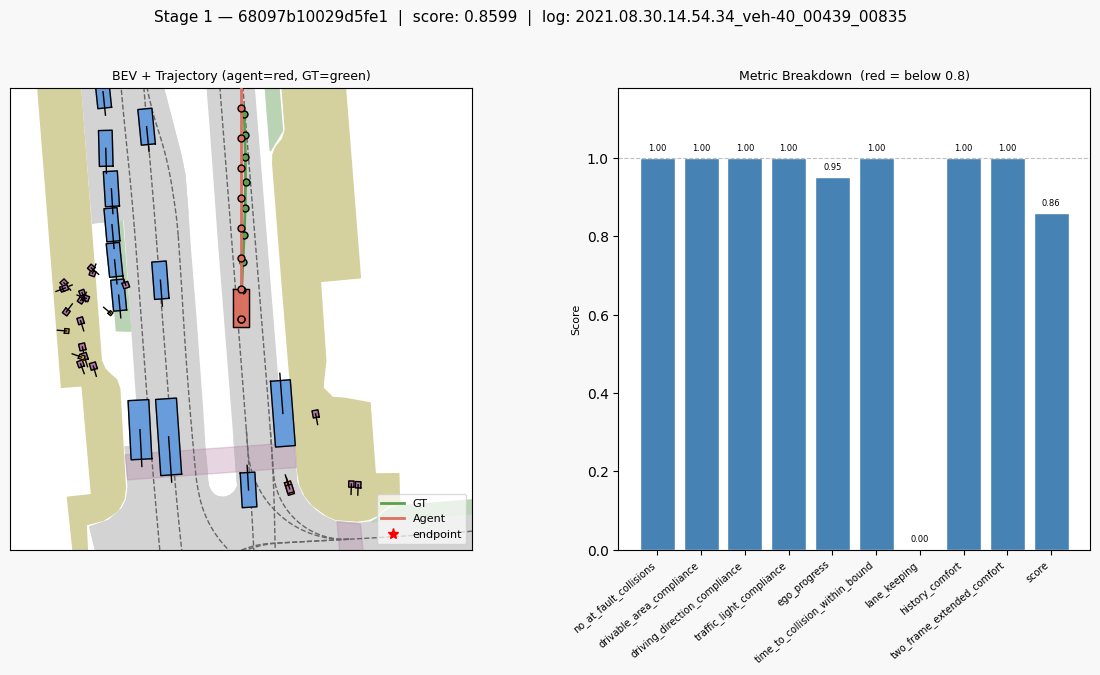

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


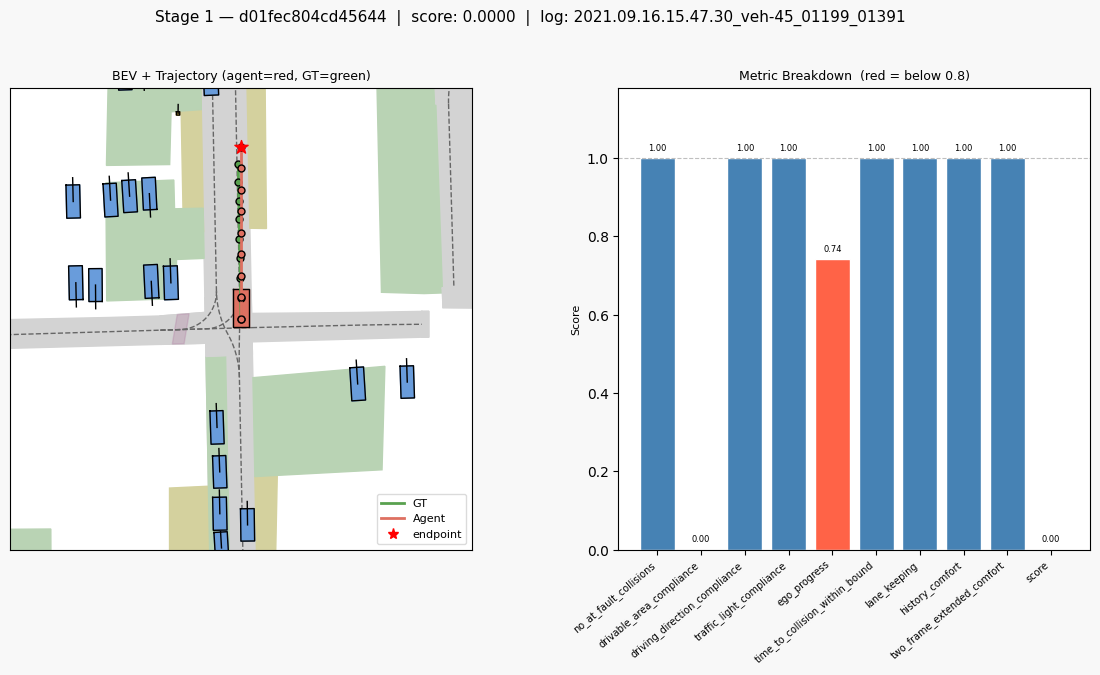

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


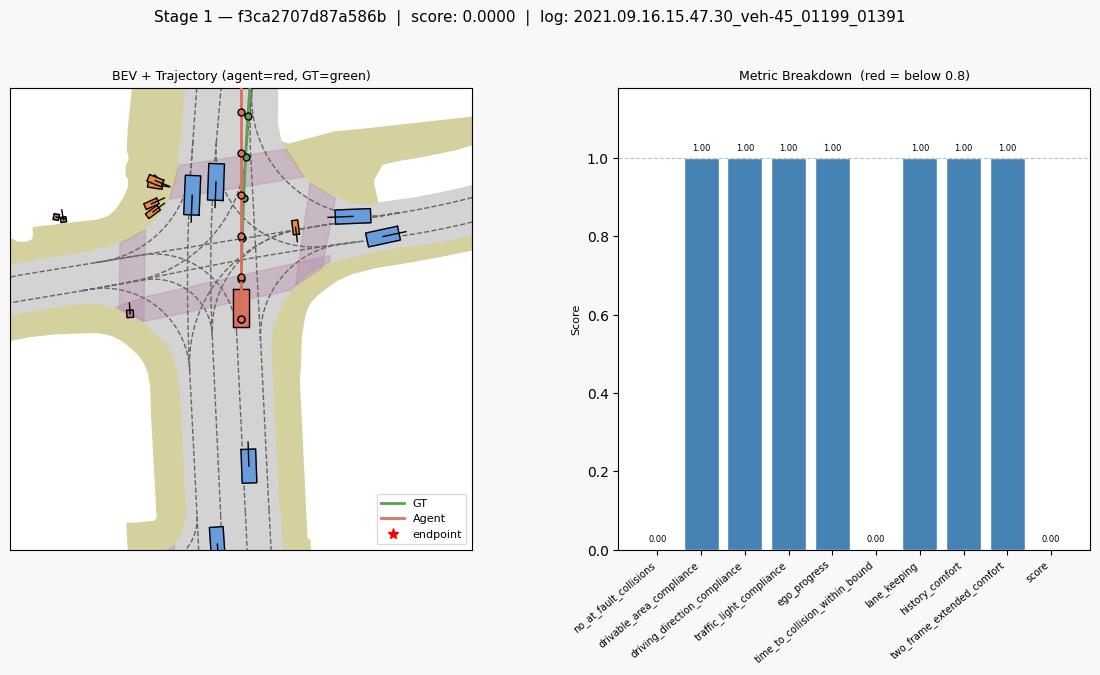

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


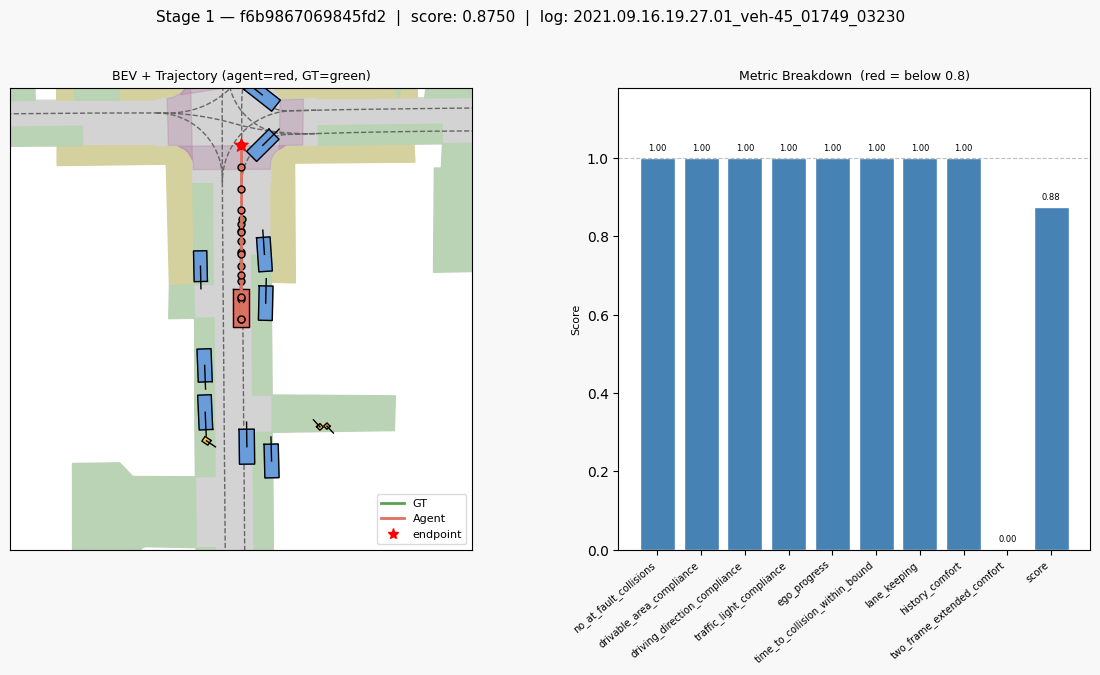

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


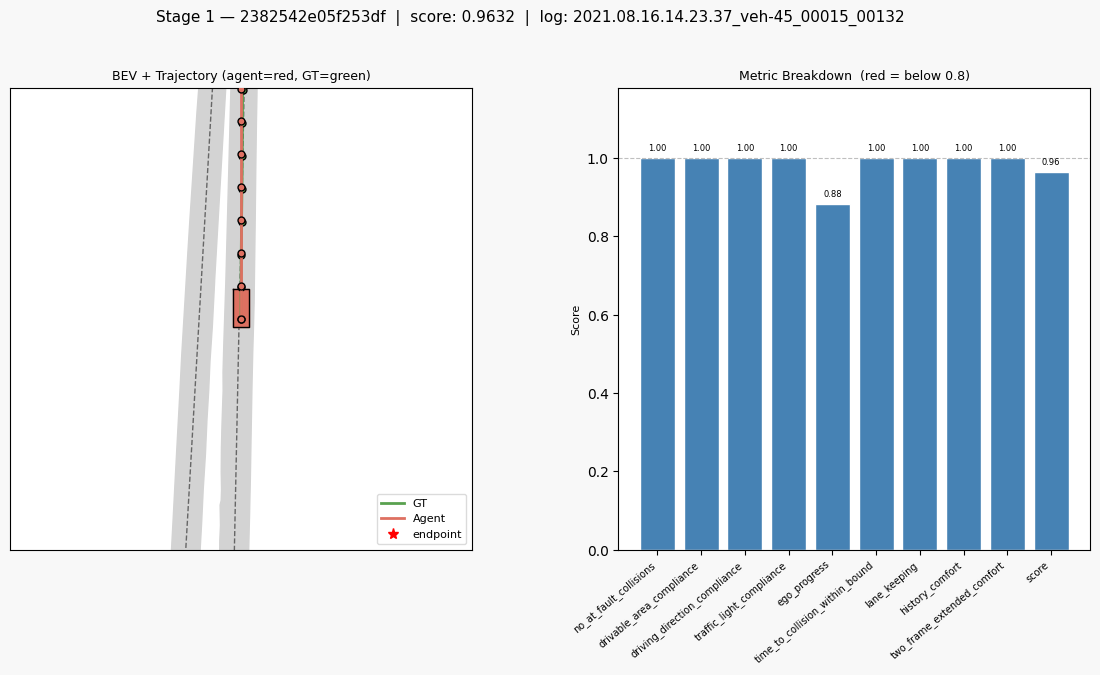

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


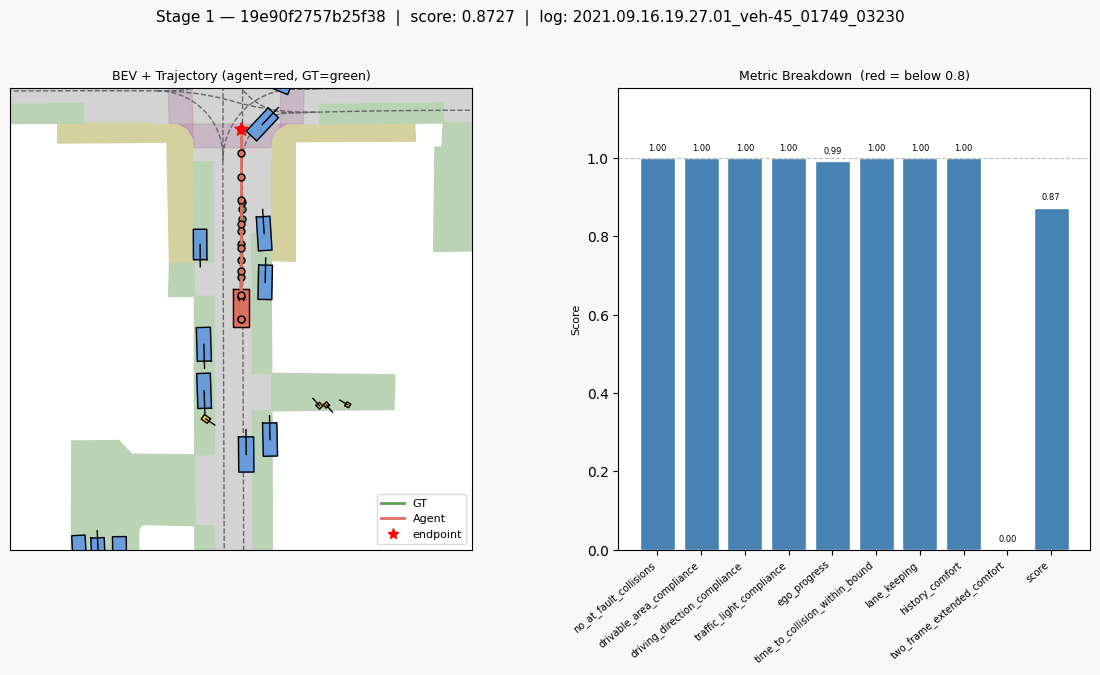

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


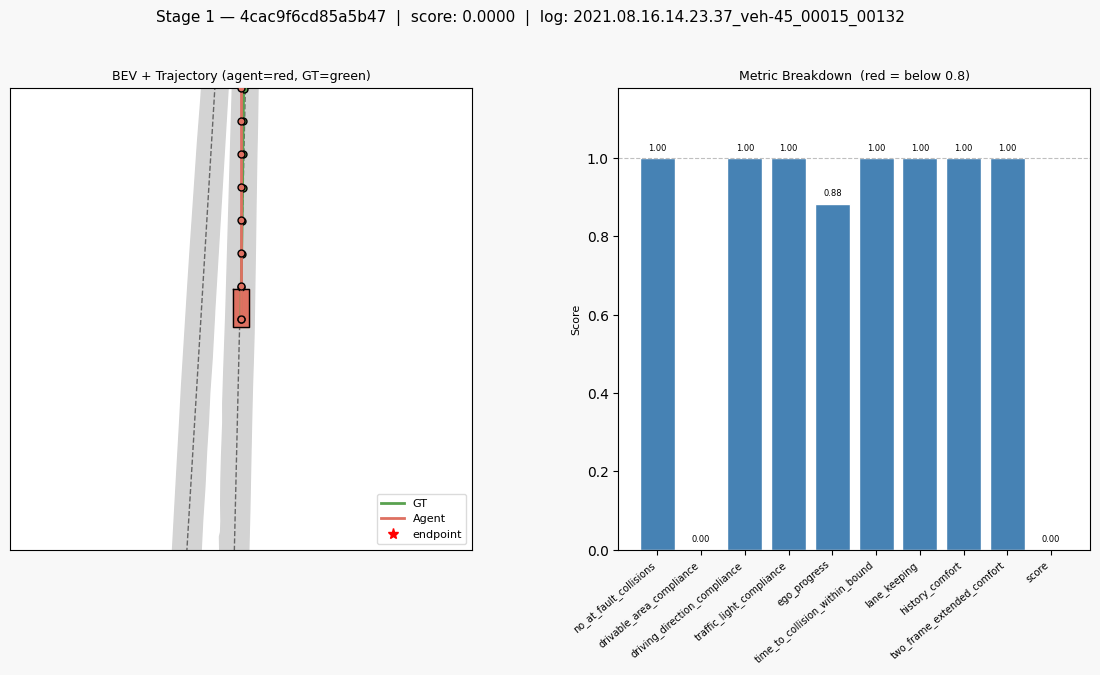

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


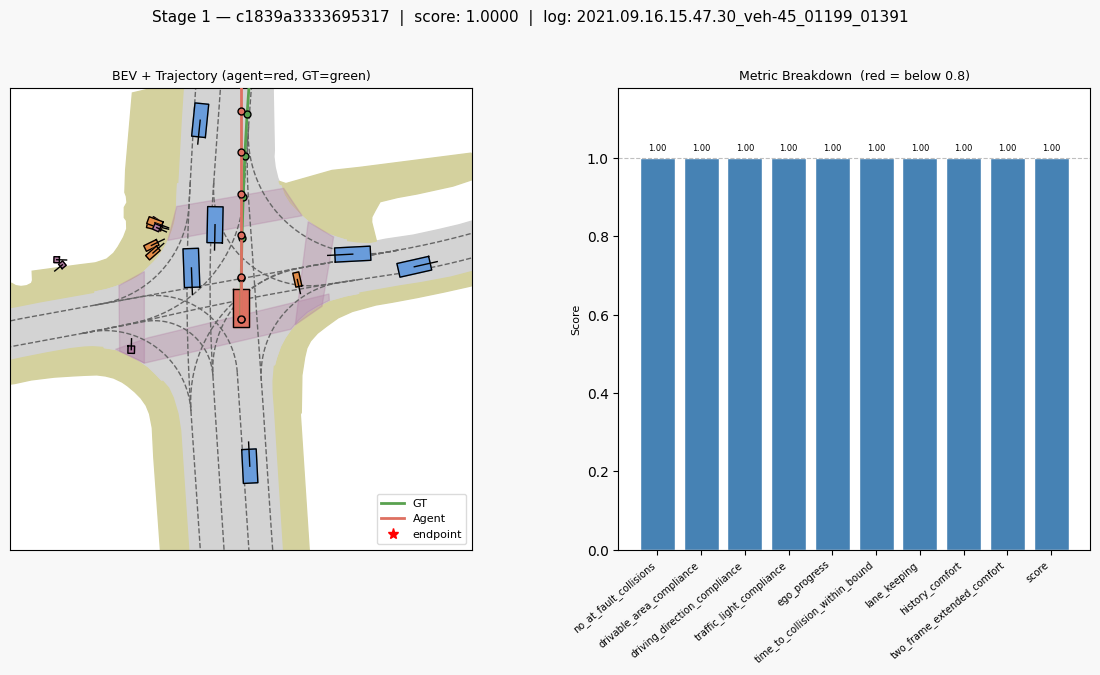

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


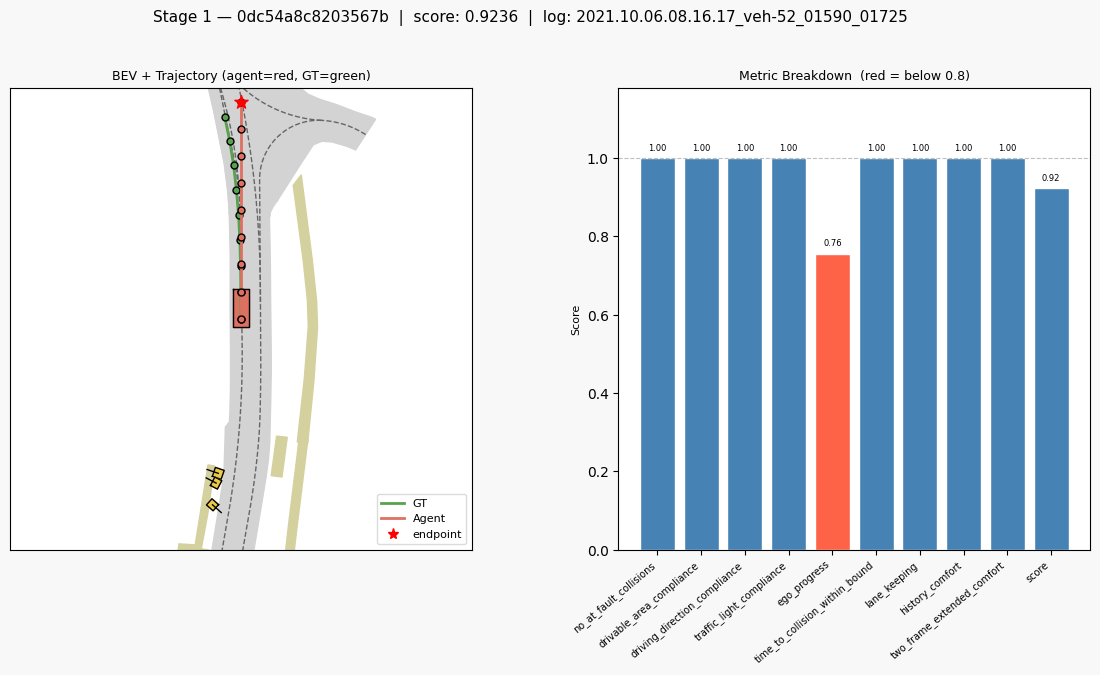

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


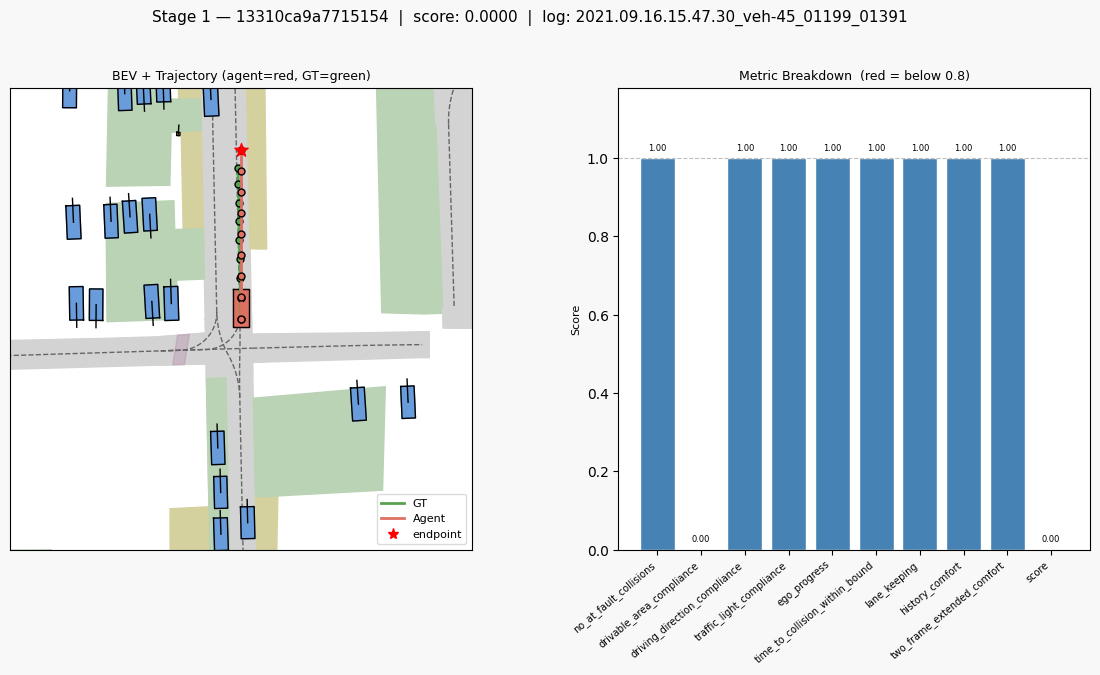

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


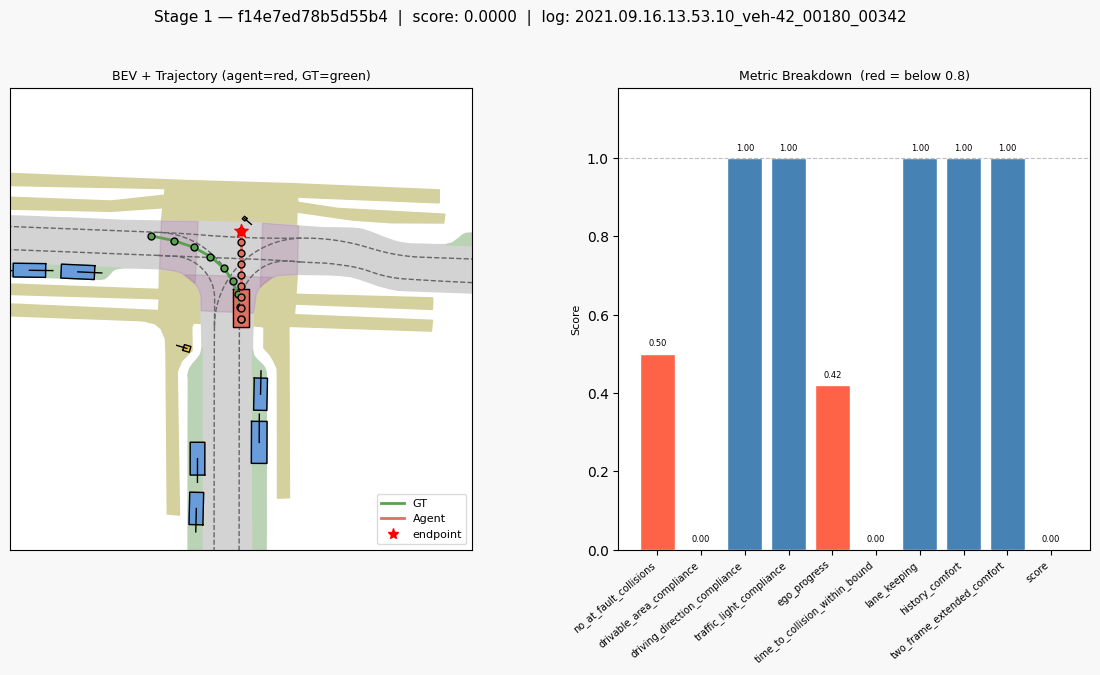

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


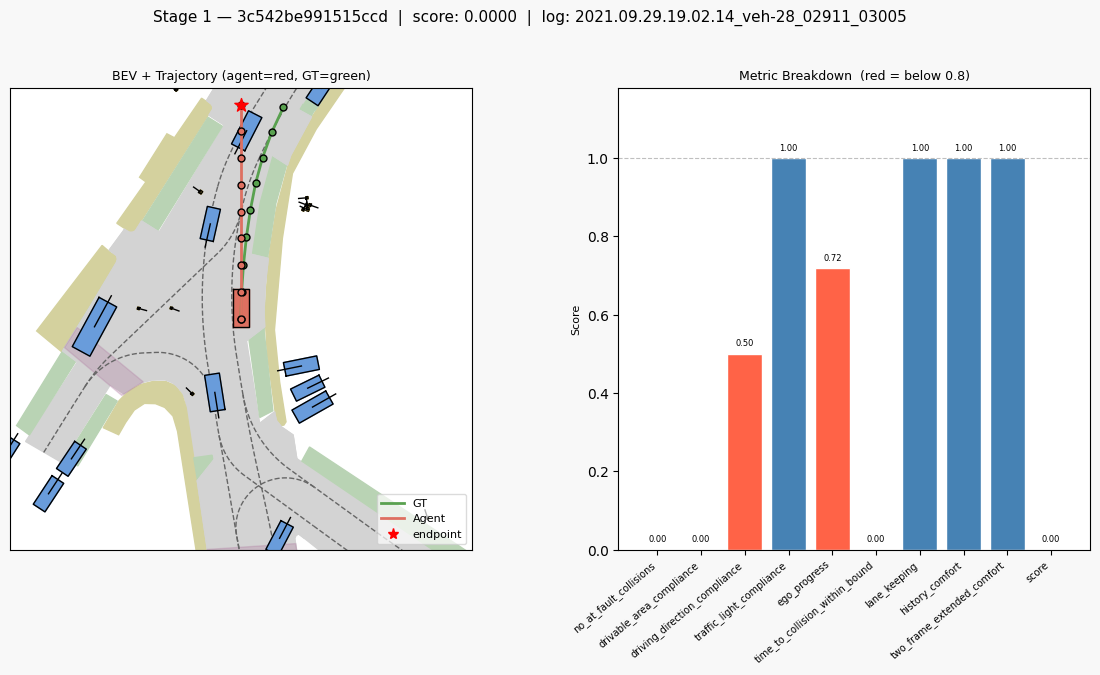

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


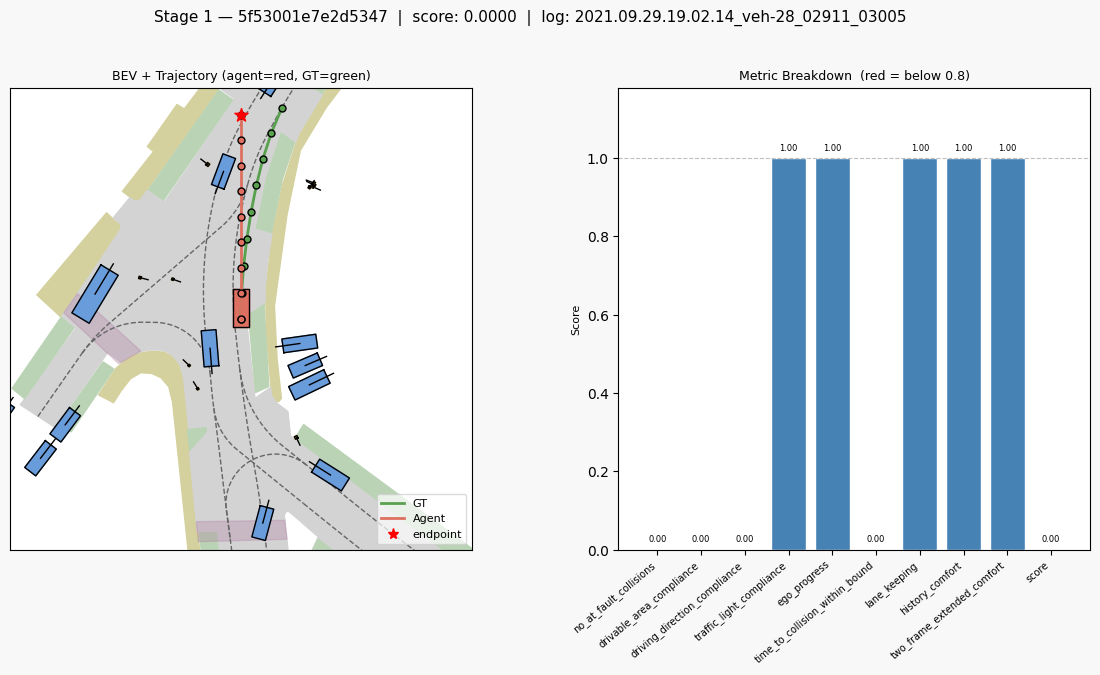

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


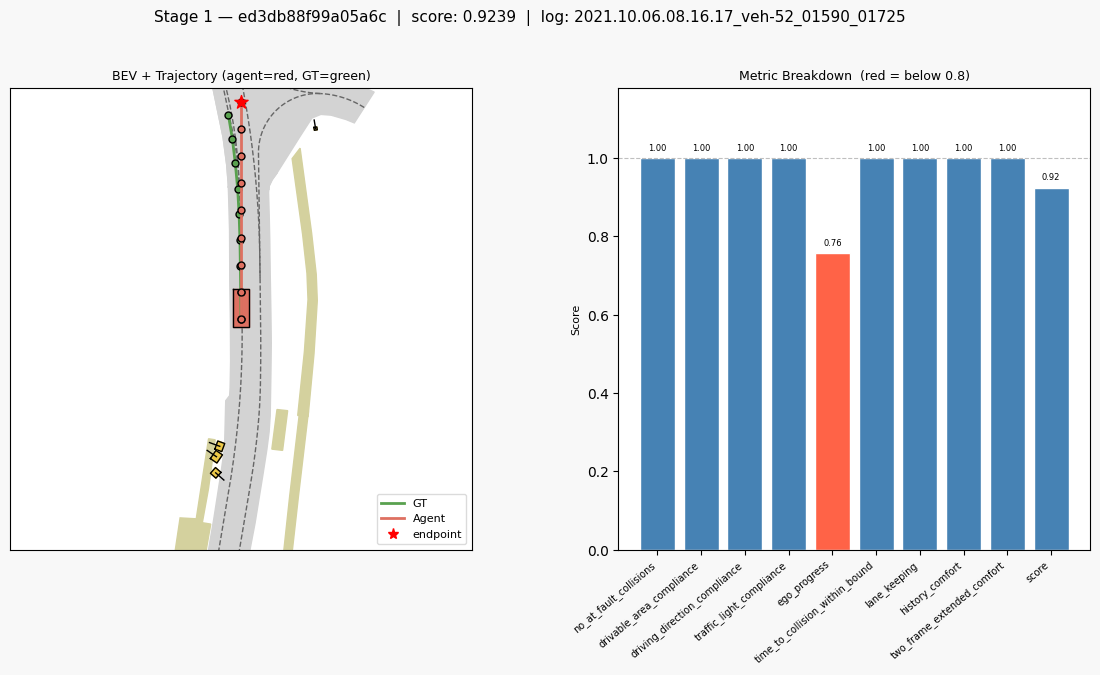

/tmp/ipykernel_134125/4184547188.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


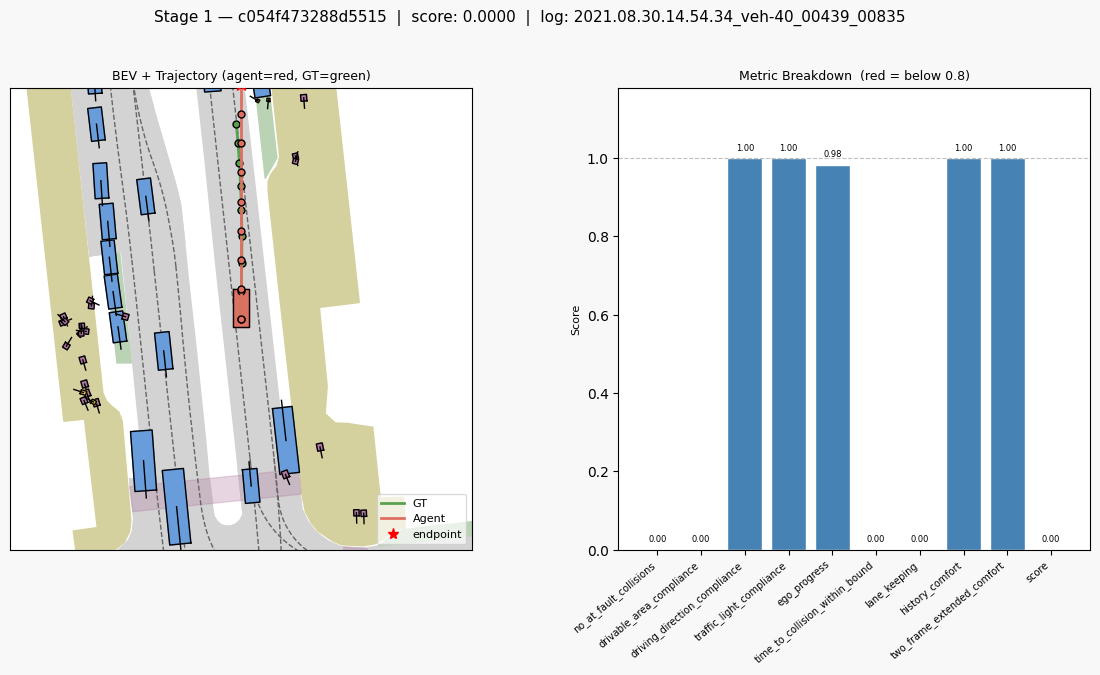

In [38]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from navsim.visualization.plots import configure_bev_ax, configure_ax
from navsim.visualization.bev import add_configured_bev_on_ax, add_trajectory_to_bev_ax
from navsim.visualization.config import TRAJECTORY_CONFIG

METRIC_DISPLAY = [
    "no_at_fault_collisions", "drivable_area_compliance", "driving_direction_compliance",
    "traffic_light_compliance", "ego_progress", "time_to_collision_within_bound",
    "lane_keeping", "history_comfort", "two_frame_extended_comfort", "score",
]

s1_viz_df = viz_df[viz_df["frame_type"] == SceneFrameType.ORIGINAL].set_index("token")

for token in stage_one_to_eval:
    scene  = s1_viz_loader.get_scene_from_token(token)
    frame  = scene.frames[cur_frame_idx]
    row    = s1_viz_df.loc[token] if token in s1_viz_df.index else None
    score_val = row["score"] if row is not None else float("nan")

    fig = plt.figure(figsize=(14, 6))
    fig.patch.set_facecolor("#f8f8f8")
    fig.suptitle(
        f"Stage 1 — {token}  |  score: {score_val:.4f}  |  log: {scene.scene_metadata.log_name}",
        fontsize=11, y=1.01,
    )
    gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)

    # ── Left: BEV with agent vs GT trajectory ────────────────────────────
    ax_bev = fig.add_subplot(gs[0, 0])

    human_traj  = scene.get_future_trajectory()
    agent_input = s1_viz_loader.get_agent_input_from_token(token)
    agent_traj  = agent.compute_trajectory(agent_input)

    add_configured_bev_on_ax(ax_bev, scene.map_api, frame)
    add_trajectory_to_bev_ax(ax_bev, human_traj, TRAJECTORY_CONFIG["human"])
    add_trajectory_to_bev_ax(ax_bev, agent_traj,  TRAJECTORY_CONFIG["agent"])

    # mark agent endpoint on BEV (last predicted pose is in ego-relative coords)
    ep = agent_traj.poses[-1]
    ax_bev.scatter([ep[1]], [ep[0]], s=100, c="red", marker="*", zorder=6)

    configure_bev_ax(ax_bev)
    configure_ax(ax_bev)
    ax_bev.legend(
        handles=[
            Line2D([0],[0], color=TRAJECTORY_CONFIG["human"]["line_color"], lw=2, label="GT"),
            Line2D([0],[0], color=TRAJECTORY_CONFIG["agent"]["line_color"],  lw=2, label="Agent"),
            Line2D([0],[0], marker="*", color="red", lw=0, markersize=8, label="endpoint"),
        ],
        loc="lower right", fontsize=8, framealpha=0.7,
    )
    ax_bev.set_title("BEV + Trajectory (agent=red, GT=green)", fontsize=9)

    # ── Right: metric score bars ──────────────────────────────────────────
    ax_bar = fig.add_subplot(gs[0, 1])
    disp_cols = [c for c in METRIC_DISPLAY if c in viz_df.columns]
    vals   = [row[c] if (row is not None and c in row.index) else np.nan for c in disp_cols]
    colors = ["tomato" if (not np.isnan(v) and v < 0.8) else "steelblue" for v in vals]
    ax_bar.bar(range(len(disp_cols)), vals, color=colors, edgecolor="white")
    ax_bar.set_xticks(range(len(disp_cols)))
    ax_bar.set_xticklabels(disp_cols, rotation=40, ha="right", fontsize=7)
    ax_bar.set_ylim(0, 1.18)
    ax_bar.set_ylabel("Score", fontsize=8)
    ax_bar.set_title("Metric Breakdown  (red = below 0.8)", fontsize=9)
    ax_bar.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax_bar.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=6)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


## 14. Stage 2 — Synthetic Scene Group Visualization

For each of the 7 mapping groups, one figure with three panels:

- **Left**: Stage 1 original scene BEV with agent trajectory and endpoint ★ (the Gaussian is centred here)
- **Centre**: Scatter of Stage 2 **global starting positions**, coloured by Gaussian weight (yellow→red = low→high); dot size ∝ score; ★ = Stage 1 endpoint
- **Right**: Stage 2 scores sorted by weight (colour = weight); blue line = weighted average that contributes to the final PCL score

Below that, the forward camera view of each Stage 2 synthetic scene is shown (sensor images are available for synthetic scenes).

/tmp/ipykernel_134125/2761951543.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_  = cm.get_cmap("YlOrRd")


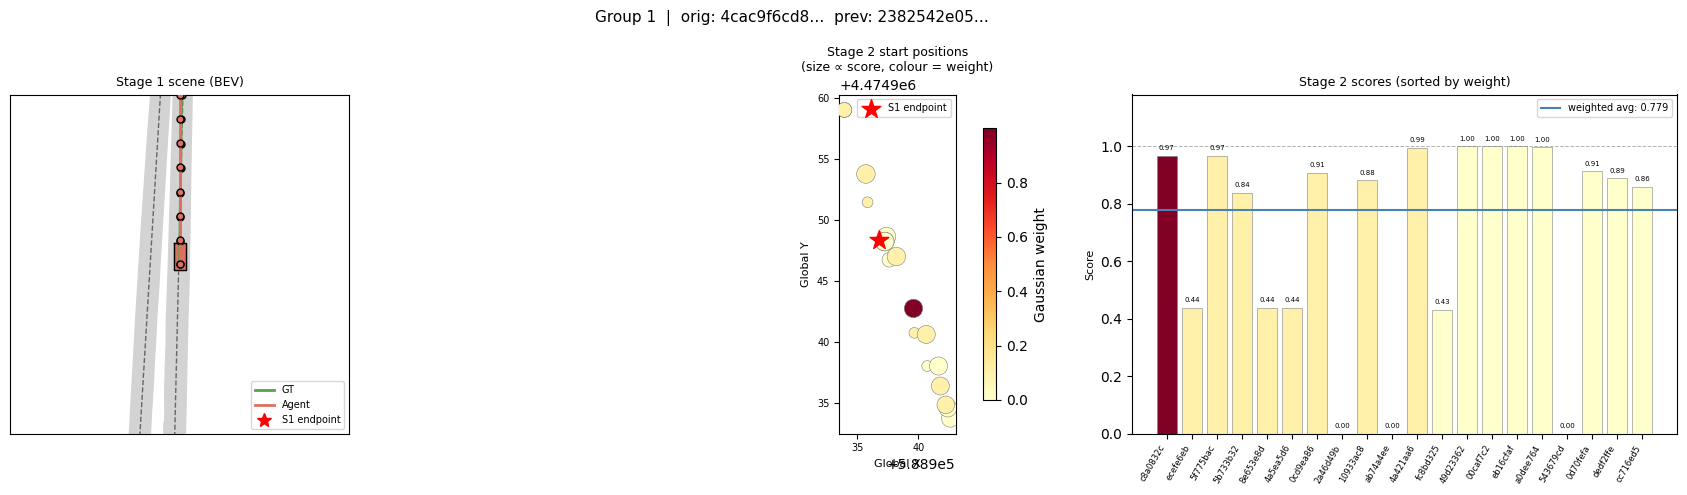

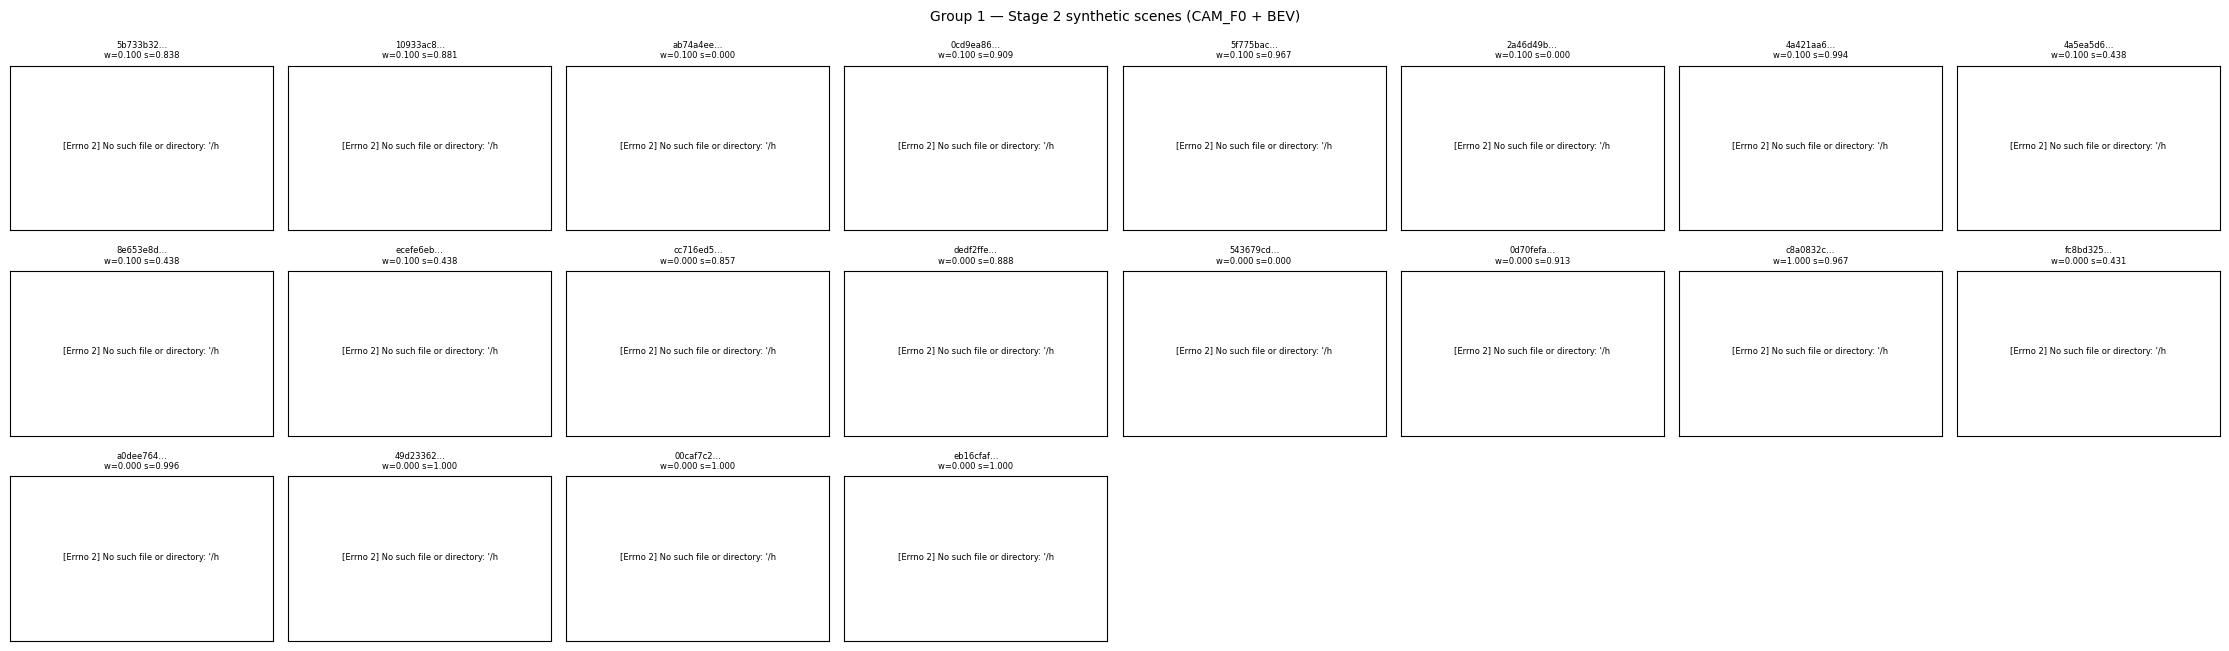

/tmp/ipykernel_134125/2761951543.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_  = cm.get_cmap("YlOrRd")


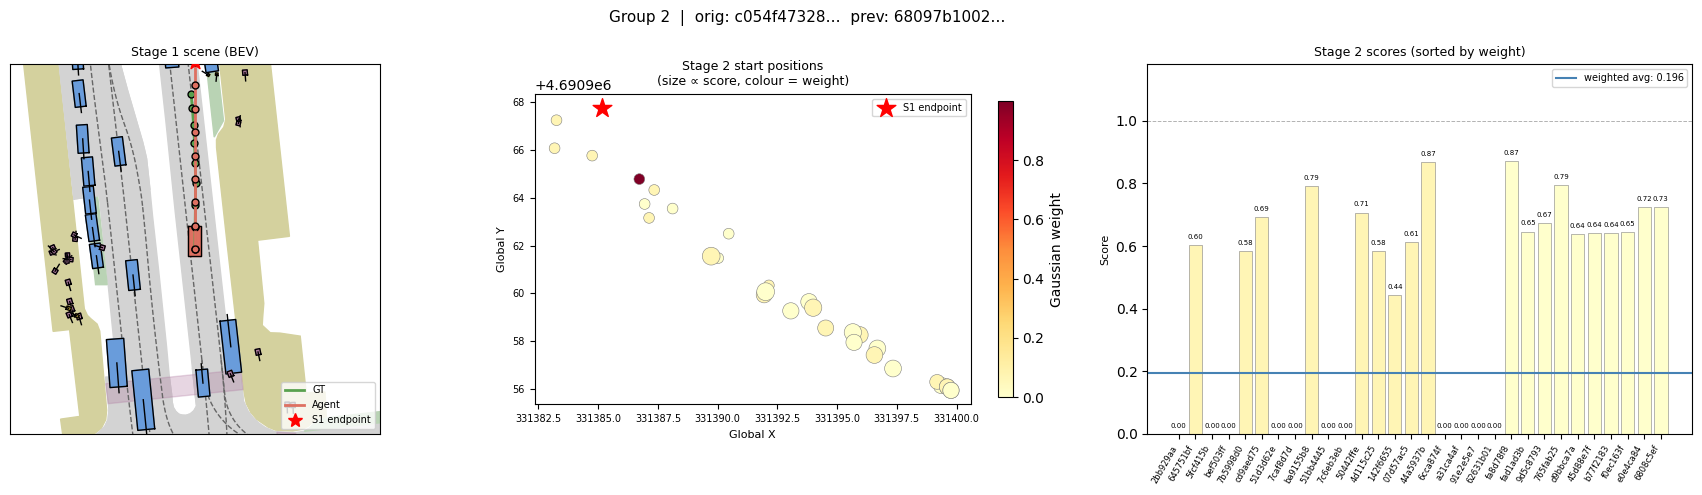

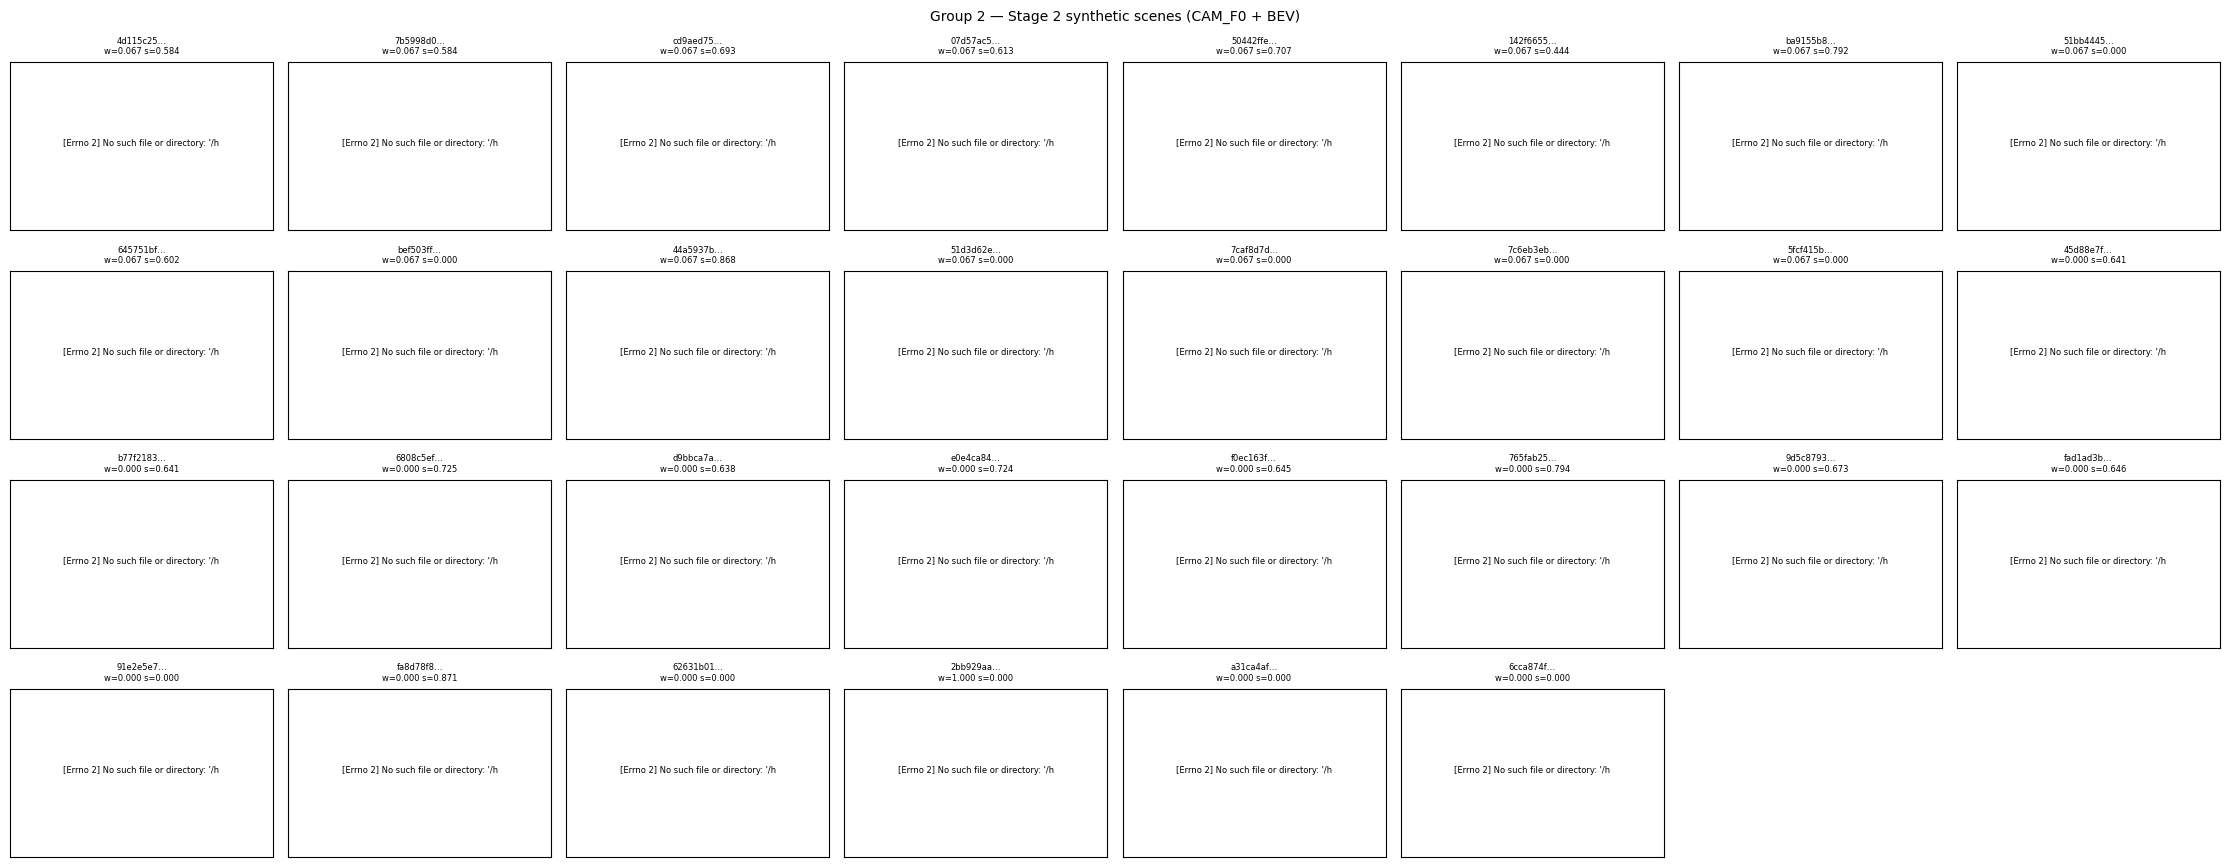

/tmp/ipykernel_134125/2761951543.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_  = cm.get_cmap("YlOrRd")


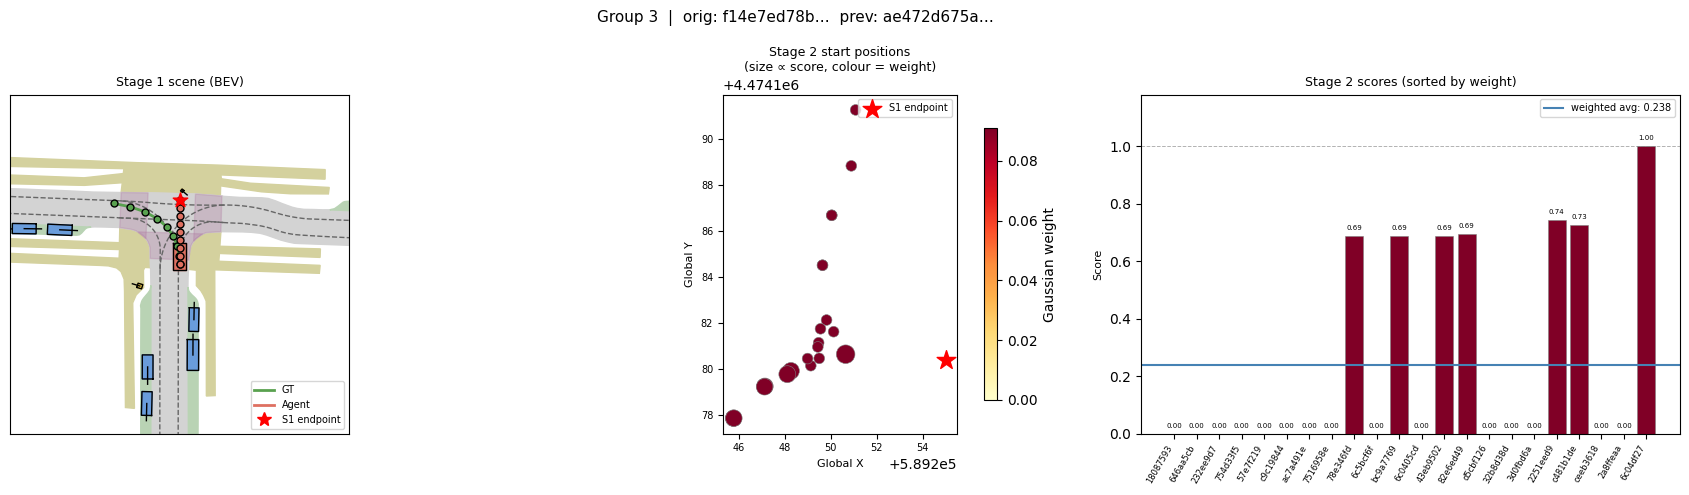

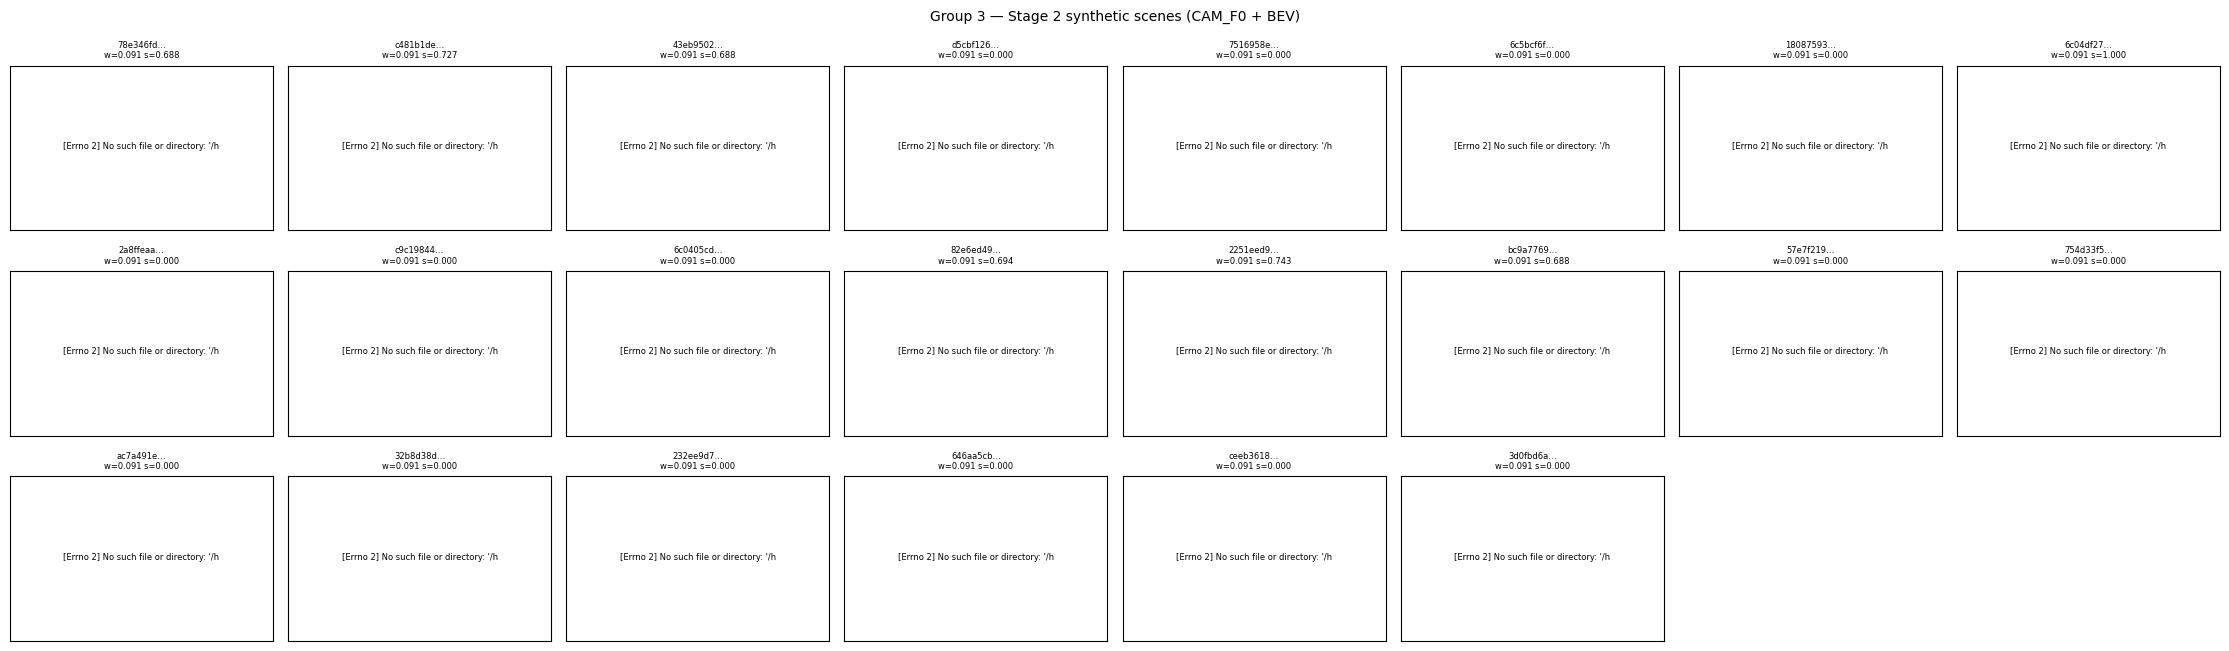

/tmp/ipykernel_134125/2761951543.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_  = cm.get_cmap("YlOrRd")


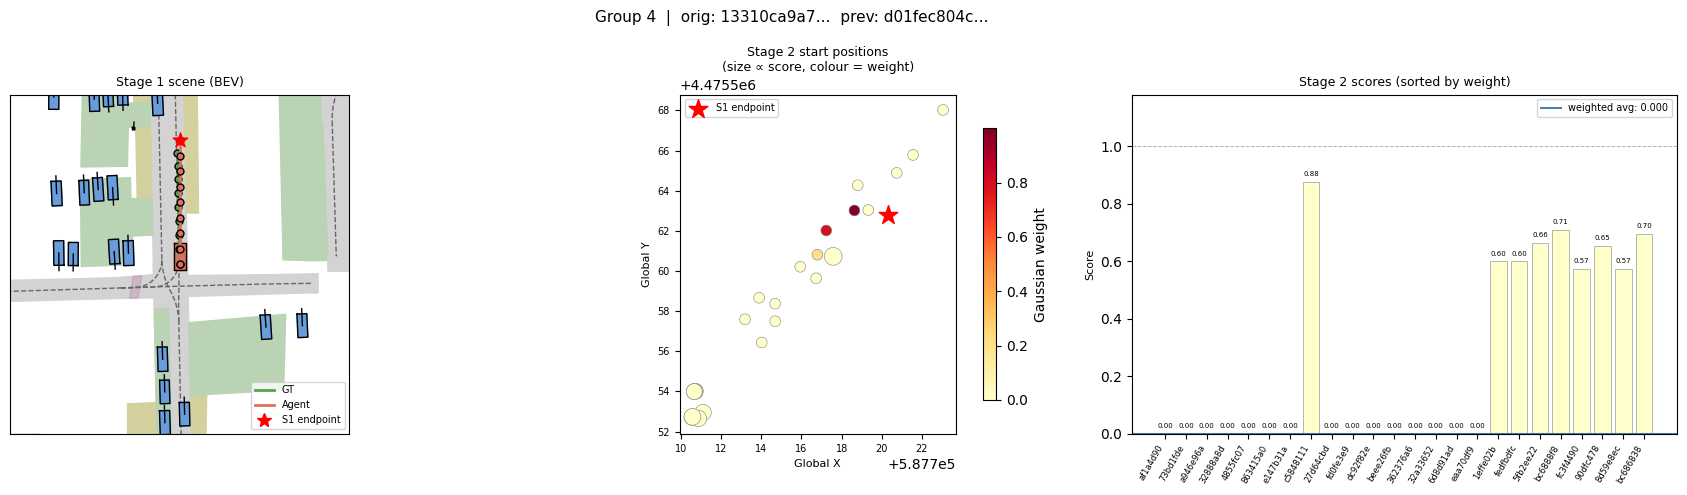

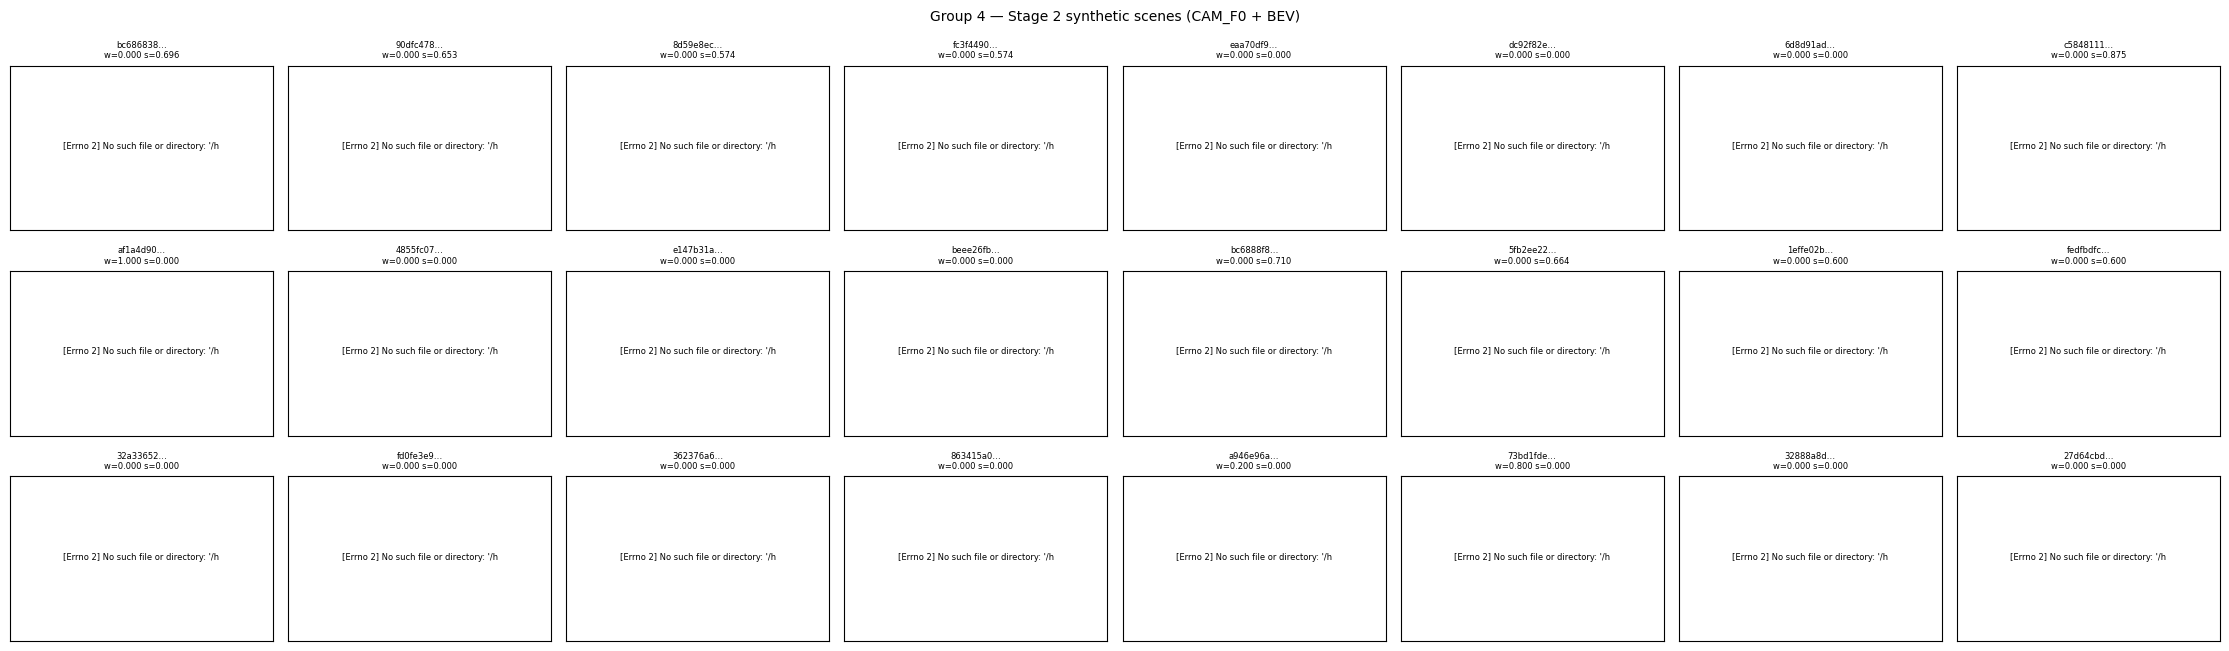

/tmp/ipykernel_134125/2761951543.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_  = cm.get_cmap("YlOrRd")


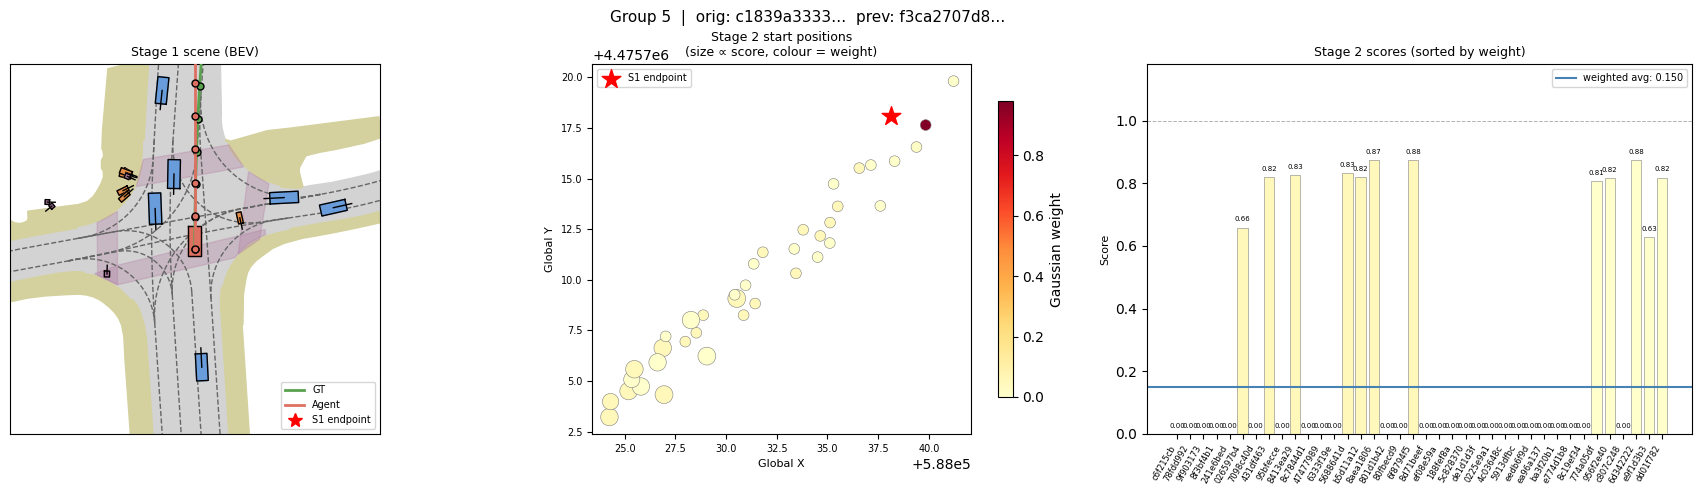

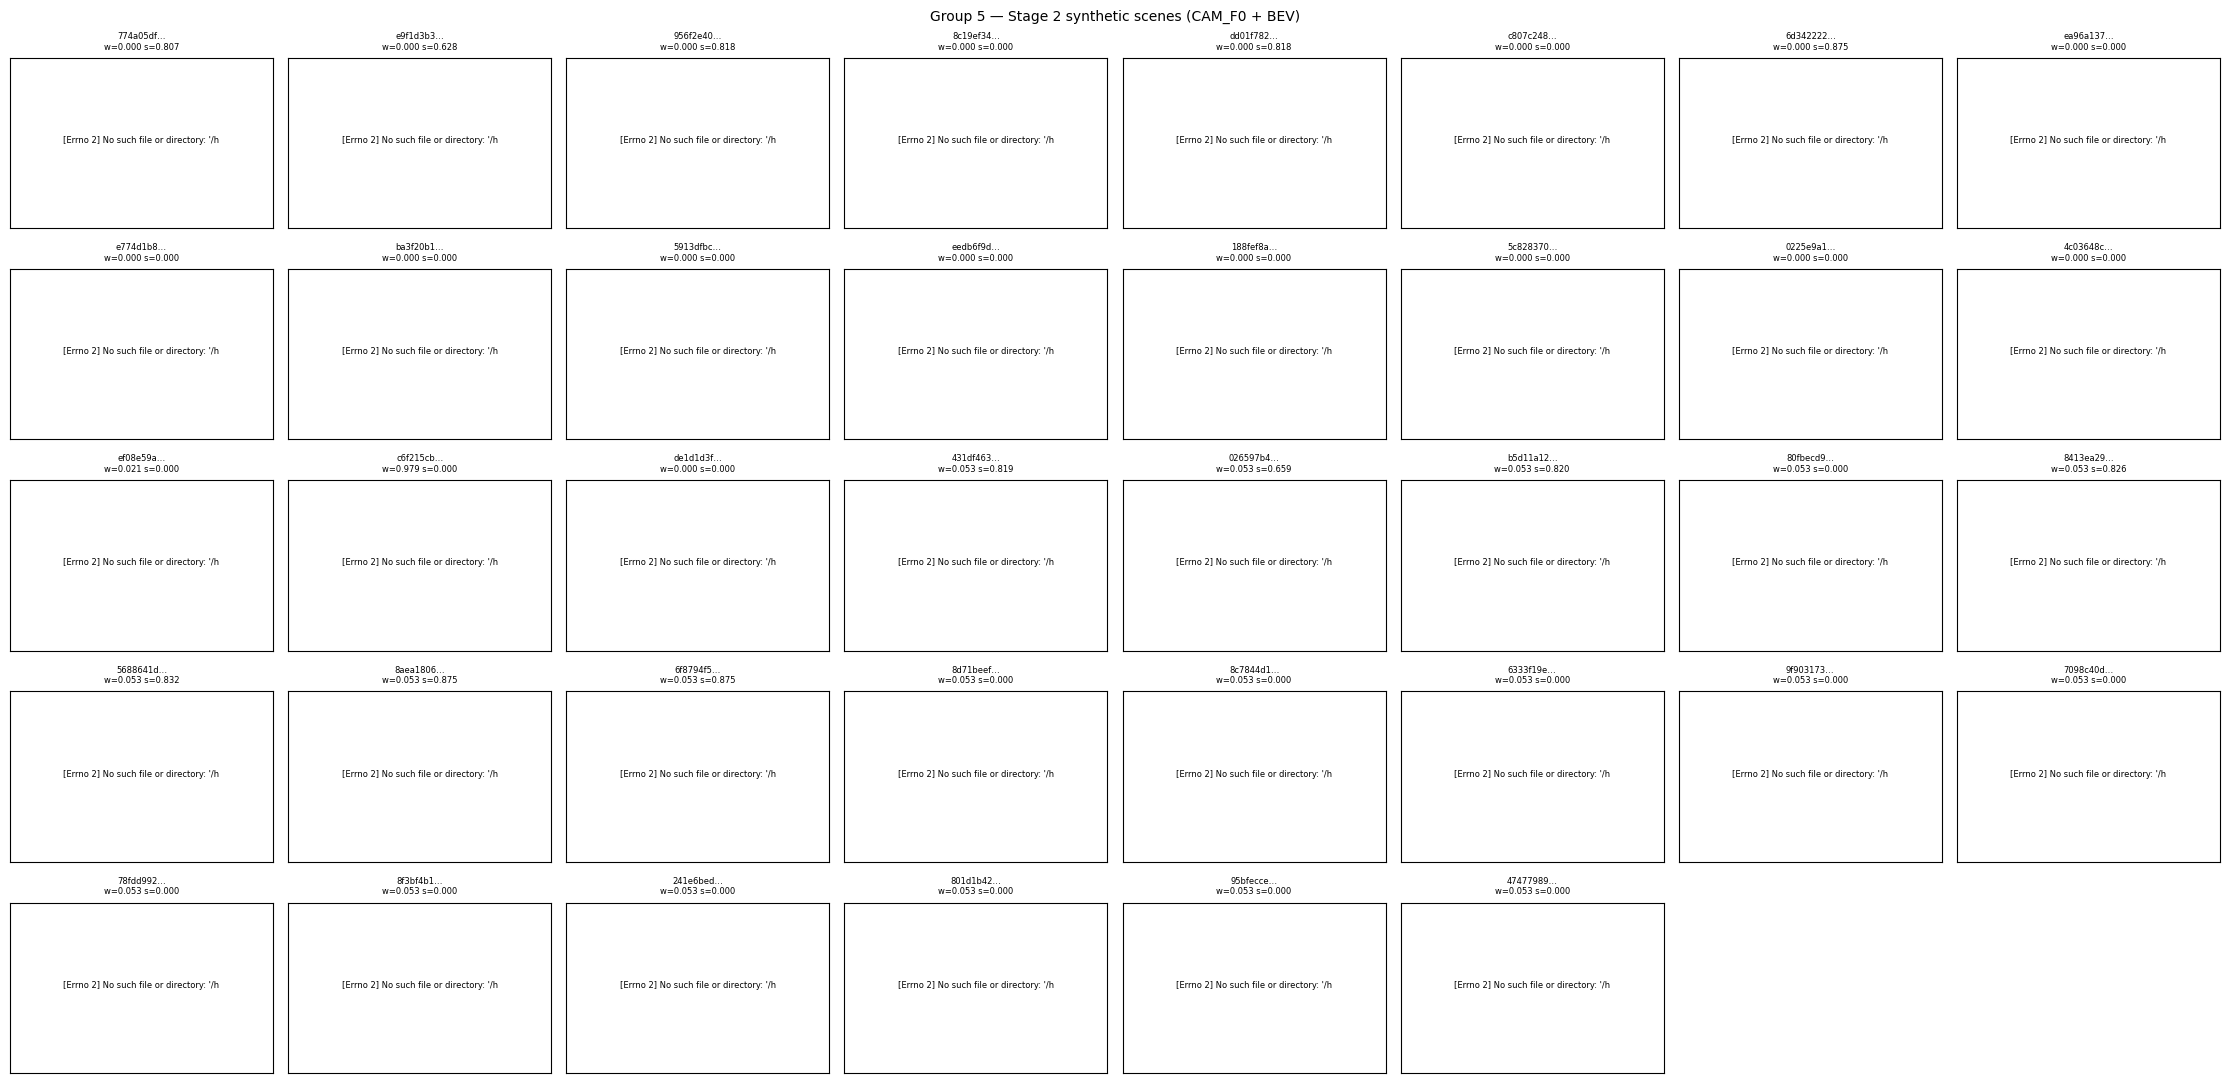

/tmp/ipykernel_134125/2761951543.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_  = cm.get_cmap("YlOrRd")


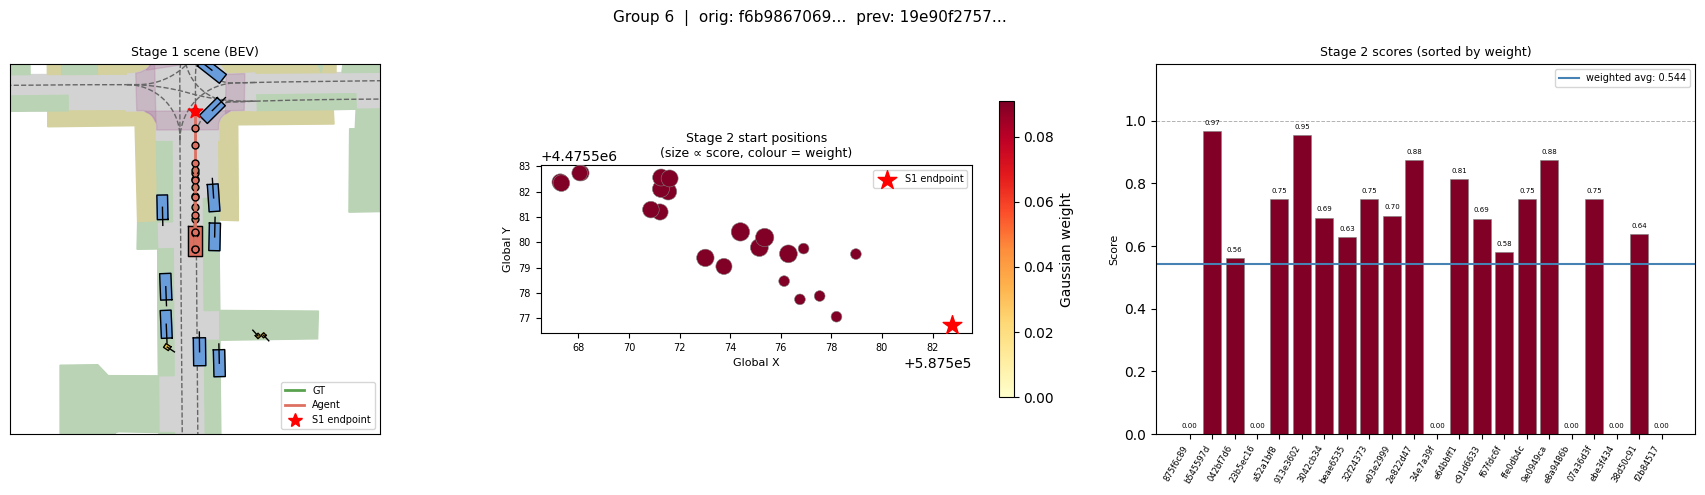

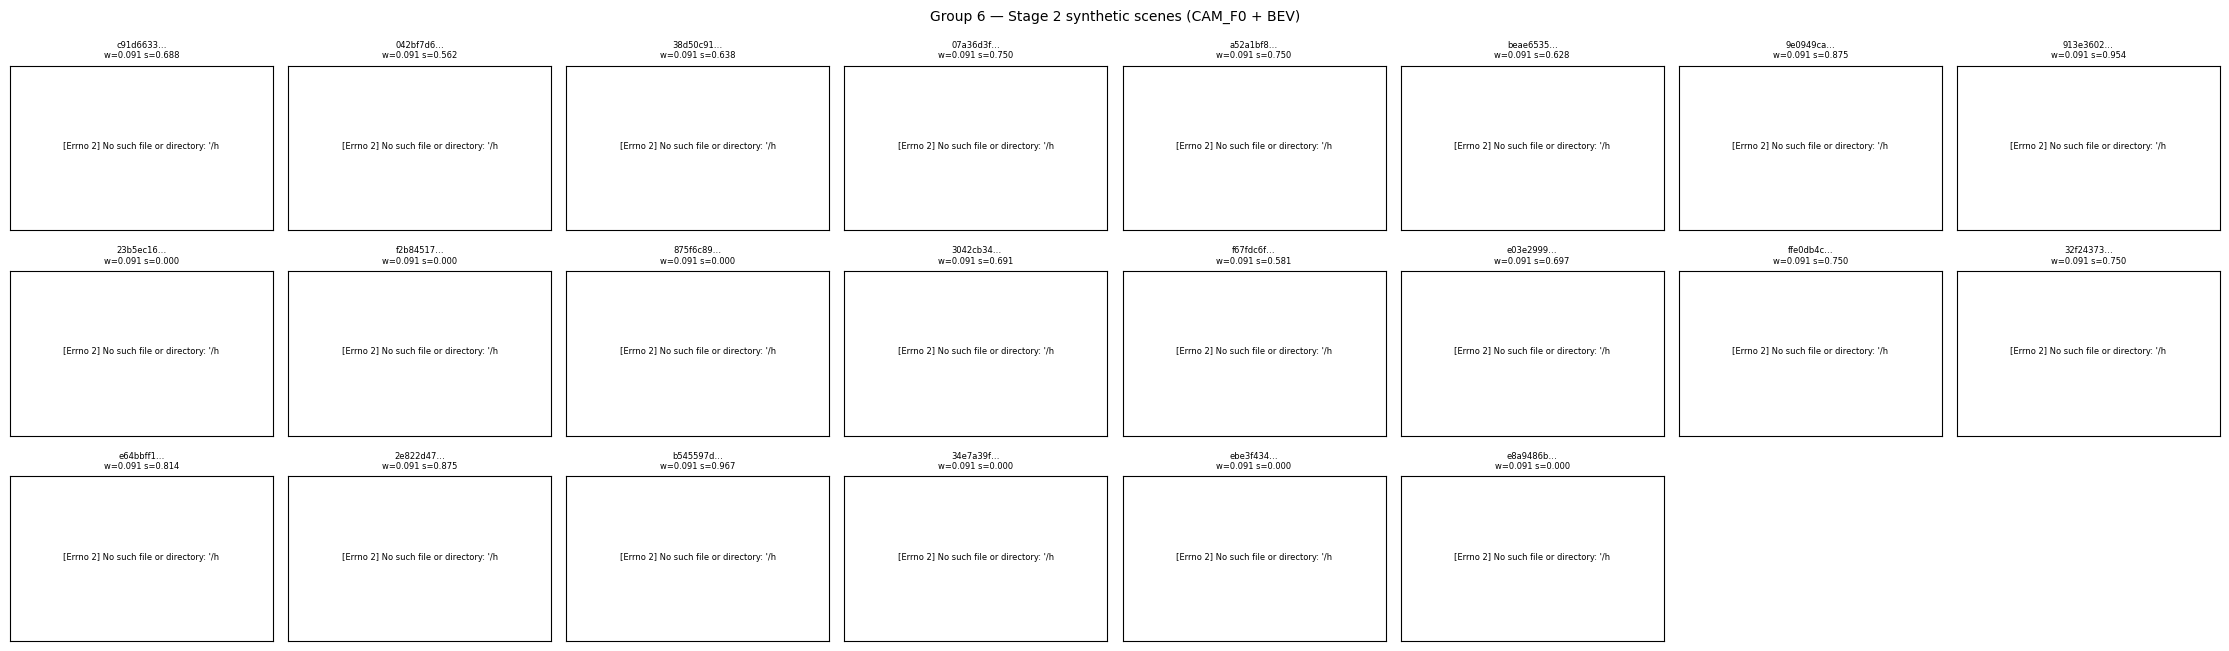

/tmp/ipykernel_134125/2761951543.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_  = cm.get_cmap("YlOrRd")


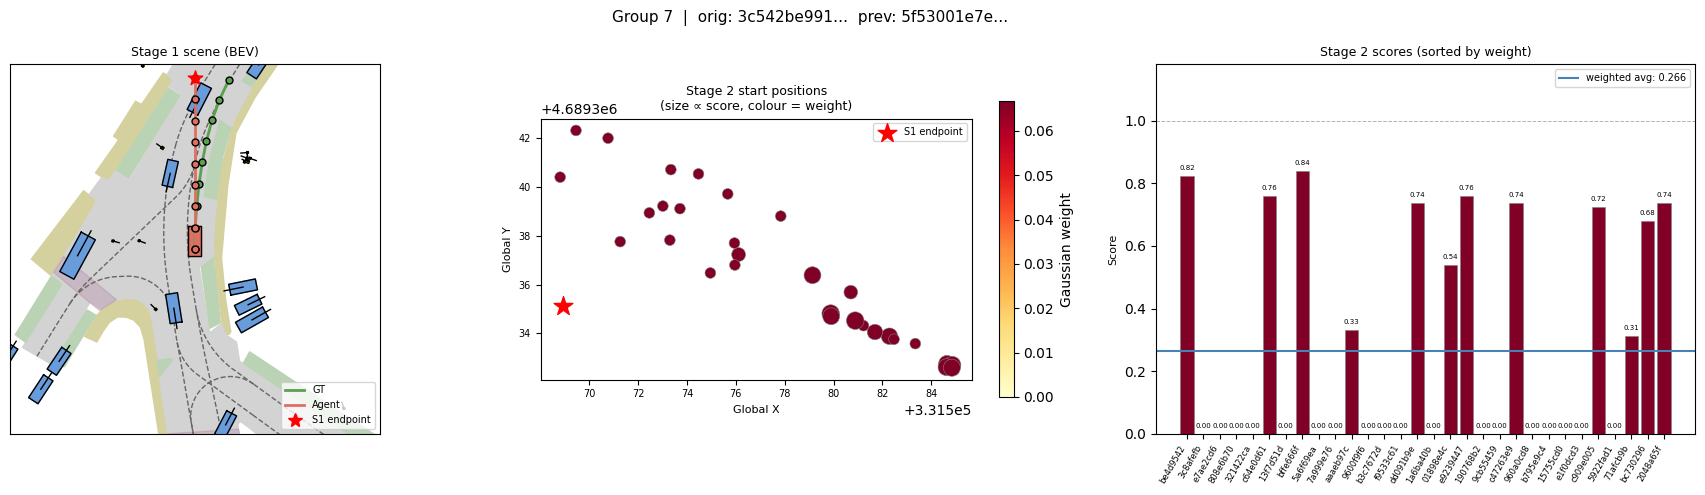

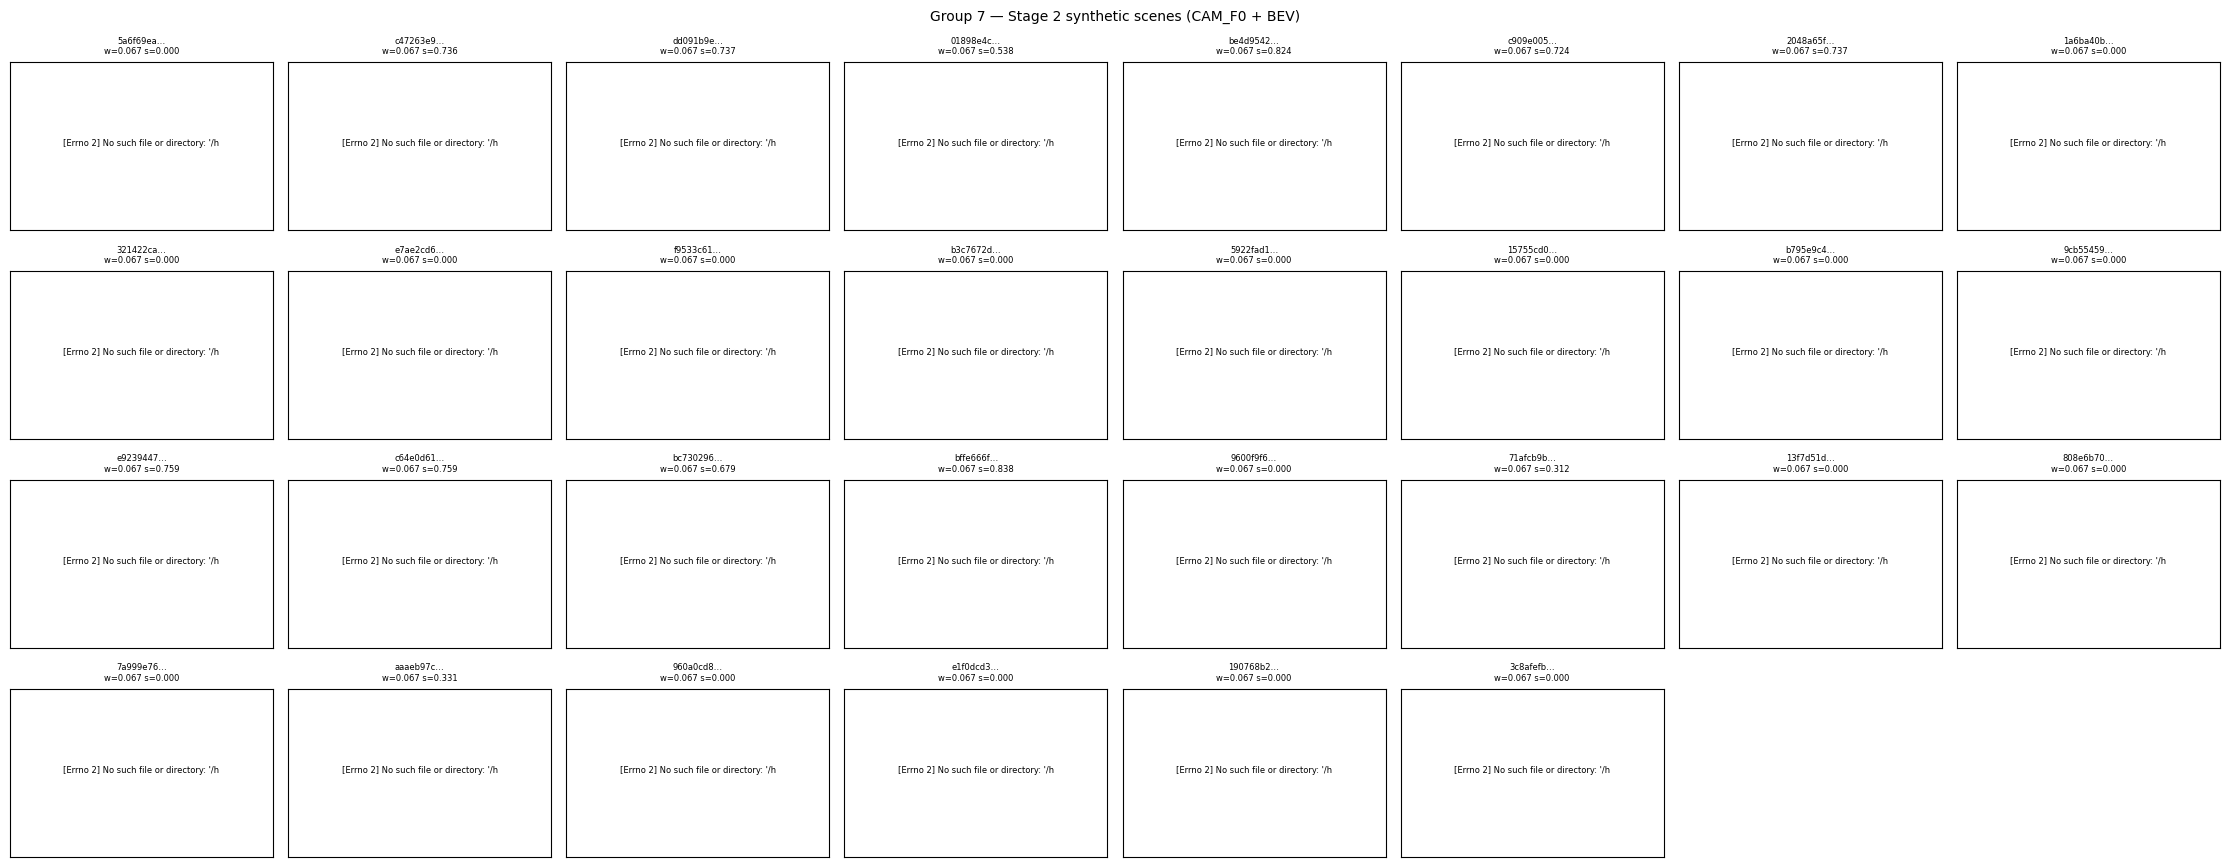

/tmp/ipykernel_134125/2761951543.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_  = cm.get_cmap("YlOrRd")


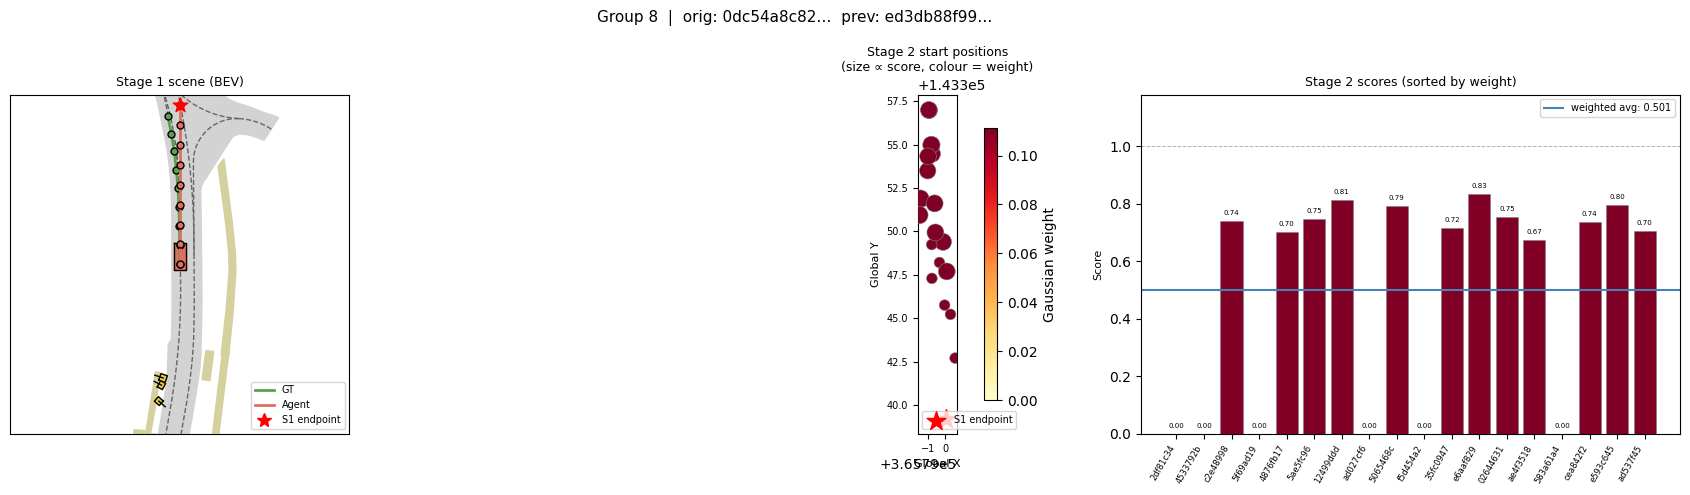

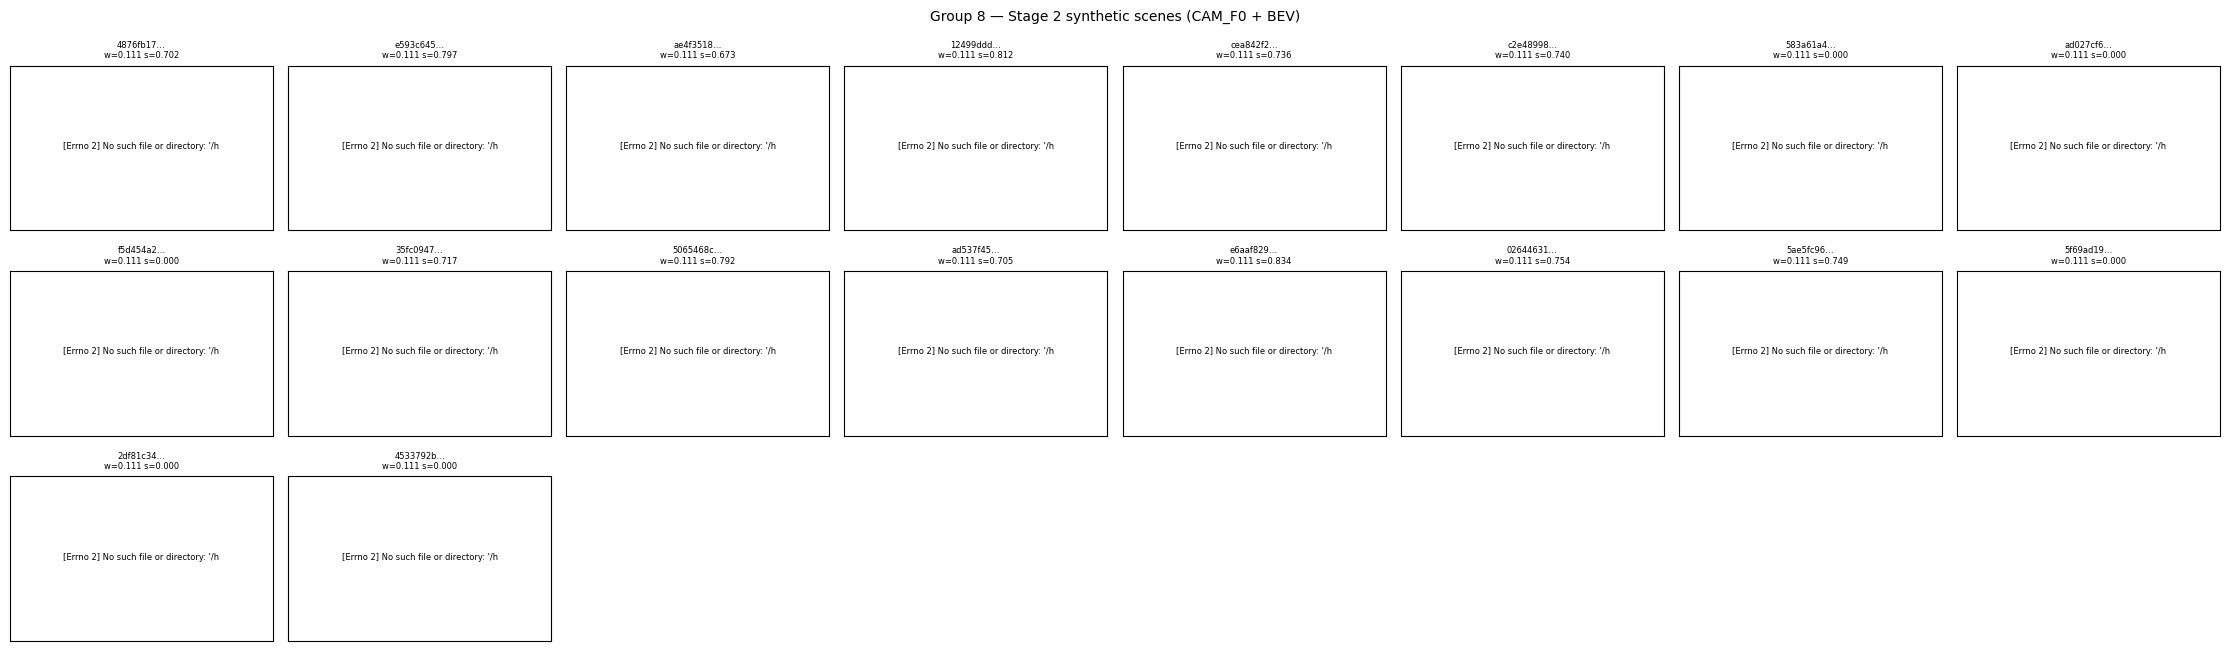

In [39]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from navsim.visualization.camera import add_annotations_to_camera_ax

s2_viz_df = viz_df[viz_df["frame_type"] == SceneFrameType.SYNTHETIC].set_index("token")

for group_idx, ((orig_token, prev_token), second_stage_pairs) in enumerate(all_mappings.items()):
    first_tokens  = [p[0] for p in second_stage_pairs if len(p) > 0]
    second_tokens = [p[1] for p in second_stage_pairs if len(p) > 1]
    s2_tokens = first_tokens + second_tokens

    group_s2 = s2_viz_df[s2_viz_df.index.isin(s2_tokens)].copy().reset_index()
    if group_s2.empty:
        continue

    s1_orig = s1_viz_df.loc[orig_token] if orig_token in s1_viz_df.index else None

    # ── Top row: Stage1 BEV | weight scatter | score bar ─────────────────
    fig_top, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig_top.suptitle(
        f"Group {group_idx+1}  |  orig: {orig_token[:10]}…  prev: {prev_token[:10]}…",
        fontsize=11,
    )

    # Left: Stage 1 BEV
    ax_s1 = axes[0]
    try:
        s1_scene = s1_viz_loader.get_scene_from_token(orig_token)
        s1_frame = s1_scene.frames[cur_frame_idx]
        add_configured_bev_on_ax(ax_s1, s1_scene.map_api, s1_frame)
        human_traj  = s1_scene.get_future_trajectory()
        agent_input = s1_viz_loader.get_agent_input_from_token(orig_token)
        agent_traj  = agent.compute_trajectory(agent_input)
        add_trajectory_to_bev_ax(ax_s1, human_traj, TRAJECTORY_CONFIG["human"])
        add_trajectory_to_bev_ax(ax_s1, agent_traj,  TRAJECTORY_CONFIG["agent"])
        ep = agent_traj.poses[-1]
        ax_s1.scatter([ep[1]], [ep[0]], s=120, c="red", marker="*", zorder=6)
        ax_s1.legend(
            handles=[
                Line2D([0],[0], color=TRAJECTORY_CONFIG["human"]["line_color"], lw=2, label="GT"),
                Line2D([0],[0], color=TRAJECTORY_CONFIG["agent"]["line_color"],  lw=2, label="Agent"),
                Line2D([0],[0], marker="*", color="red", lw=0, markersize=10, label="S1 endpoint"),
            ],
            loc="lower right", fontsize=7,
        )
    except Exception as e:
        ax_s1.text(0.5, 0.5, f"Error: {e}", transform=ax_s1.transAxes, ha="center", fontsize=7)
    configure_bev_ax(ax_s1); configure_ax(ax_s1)
    ax_s1.set_title("Stage 1 scene (BEV)", fontsize=9)

    # Centre: weight scatter
    ax_sc = axes[1]
    has_xy = ("start_point_x" in group_s2.columns and "weight" in group_s2.columns)
    if has_xy and s1_orig is not None:
        sx = group_s2["start_point_x"].to_numpy(dtype=float)
        sy = group_s2["start_point_y"].to_numpy(dtype=float)
        weights = group_s2["weight"].to_numpy(dtype=float)
        scores  = group_s2["score"].to_numpy(dtype=float)
        valid = ~(np.isnan(sx) | np.isnan(sy) | np.isnan(weights))
        ep_x = s1_orig.get("endpoint_x", np.nan)
        ep_y = s1_orig.get("endpoint_y", np.nan)
        if valid.any():
            sc = ax_sc.scatter(
                sx[valid], sy[valid],
                c=weights[valid], cmap="YlOrRd",
                s=60 + 120 * np.nan_to_num(scores[valid]),
                edgecolors="gray", linewidths=0.4,
                vmin=0, vmax=weights[valid].max() or 1, zorder=3,
            )
            plt.colorbar(sc, ax=ax_sc, label="Gaussian weight", shrink=0.8)
        if not (np.isnan(ep_x) or np.isnan(ep_y)):
            ax_sc.scatter([ep_x], [ep_y], s=200, c="red", marker="*", zorder=5, label="S1 endpoint")
            ax_sc.legend(fontsize=7)
        ax_sc.set_xlabel("Global X", fontsize=8); ax_sc.set_ylabel("Global Y", fontsize=8)
        ax_sc.tick_params(labelsize=7); ax_sc.set_aspect("equal")
    ax_sc.set_title("Stage 2 start positions\n(size ∝ score, colour = weight)", fontsize=9)

    # Right: score bar sorted by weight
    ax_bar = axes[2]
    if "weight" in group_s2.columns and "score" in group_s2.columns:
        sorted_g2 = group_s2[["token","weight","score"]].dropna(subset=["weight","score"])
        sorted_g2 = sorted_g2.sort_values("weight", ascending=False).reset_index(drop=True)
        w_vals = sorted_g2["weight"].to_numpy(dtype=float)
        s_vals = sorted_g2["score"].to_numpy(dtype=float)
        norm   = mcolors.Normalize(vmin=0, vmax=w_vals.max() or 1)
        cmap_  = cm.get_cmap("YlOrRd")
        ax_bar.bar(range(len(s_vals)), s_vals,
                   color=[cmap_(norm(w)) for w in w_vals],
                   edgecolor="gray", linewidth=0.4)
        ax_bar.set_xticks(range(len(s_vals)))
        ax_bar.set_xticklabels(sorted_g2["token"].str[:8].tolist(), rotation=60, ha="right", fontsize=6)
        ax_bar.set_ylim(0, 1.18); ax_bar.set_ylabel("Score", fontsize=8)
        ax_bar.axhline(1.0, color="gray", linestyle="--", linewidth=0.7, alpha=0.6)
        total_w = w_vals.sum()
        if total_w > 0:
            w_avg = (s_vals * w_vals).sum() / total_w
            ax_bar.axhline(w_avg, color="steelblue", lw=1.5, label=f"weighted avg: {w_avg:.3f}")
            ax_bar.legend(fontsize=7)
        for i, (s, w) in enumerate(zip(s_vals, w_vals)):
            ax_bar.text(i, s + 0.02, f"{s:.2f}", ha="center", fontsize=5)
    ax_bar.set_title("Stage 2 scores (sorted by weight)", fontsize=9)

    fig_top.tight_layout()
    plt.show(); plt.close(fig_top)

    # ── Camera row: forward cam (CAM_F0) for each Stage 2 scene ──────────
    valid_s2_tokens = [t for t in s2_tokens if t in s2_viz_df.index]
    if valid_s2_tokens:
        n = len(valid_s2_tokens)
        ncols = min(n, 8)
        nrows = (n + ncols - 1) // ncols
        fig_cam, cam_axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 2.2))
        fig_cam.suptitle(
            f"Group {group_idx+1} — Stage 2 synthetic scenes (CAM_F0 + BEV)", fontsize=10
        )
        cam_axes_flat = [cam_axes] if n == 1 else (
            [ax for row in cam_axes for ax in row] if nrows > 1 else list(cam_axes)
        )
        for ax_i, tok in enumerate(valid_s2_tokens):
            ax = cam_axes_flat[ax_i]
            try:
                s2_scene = s2_viz_loader.get_scene_from_token(tok)
                s2_frame = s2_scene.frames[cur_frame_idx]
                add_annotations_to_camera_ax(ax, s2_frame.cameras.cam_f0, s2_frame.annotations)
            except Exception as e:
                ax.text(0.5, 0.5, str(e)[:40], transform=ax.transAxes, ha="center", fontsize=6)
            w_val = group_s2.set_index("token").loc[tok, "weight"] if tok in group_s2["token"].values else np.nan
            s_val = group_s2.set_index("token").loc[tok, "score"]  if tok in group_s2["token"].values else np.nan
            ax.set_title(f"{tok[:8]}…\nw={w_val:.3f} s={s_val:.3f}", fontsize=6)
            ax.set_xticks([]); ax.set_yticks([])
        for ax_i in range(len(valid_s2_tokens), len(cam_axes_flat)):
            cam_axes_flat[ax_i].axis("off")
        fig_cam.tight_layout()
        plt.show(); plt.close(fig_cam)


## 15. Summary: Stage 1 vs Stage 2 Metric Breakdown

Average metric scores across all Stage 1 and Stage 2 tokens, side by side.
The combined PCL score = mean over groups of (Stage 1 × Stage 2).

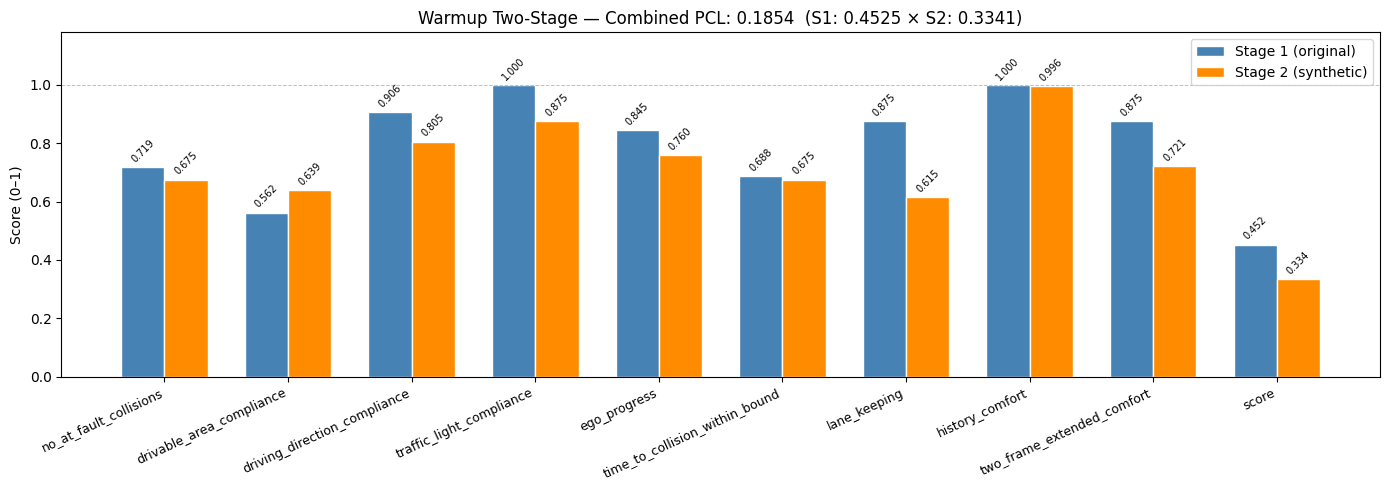

In [40]:
base_metrics = [
    "no_at_fault_collisions", "drivable_area_compliance", "driving_direction_compliance",
    "traffic_light_compliance", "ego_progress", "time_to_collision_within_bound",
    "lane_keeping", "history_comfort", "two_frame_extended_comfort", "score",
]

s1_vals = [pcl_stage1.get(m, np.nan) for m in base_metrics]
s2_vals = [pcl_stage2.get(m, np.nan) for m in base_metrics]

x     = np.arange(len(base_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width/2, s1_vals, width, label="Stage 1 (original)",  color="steelblue",  edgecolor="white")
bars2 = ax.bar(x + width/2, s2_vals, width, label="Stage 2 (synthetic)", color="darkorange", edgecolor="white")

for bar, val in zip(list(bars1) + list(bars2), s1_vals + s2_vals):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
                ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(base_metrics, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Score (0–1)")
ax.set_ylim(0, 1.18)
ax.set_title(
    f"Warmup Two-Stage — Combined PCL: {pcl_combined.get('score', float('nan')):.4f}"
    f"  (S1: {pcl_stage1.get('score', float('nan')):.4f} × S2: {pcl_stage2.get('score', float('nan')):.4f})"
)
ax.legend()
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.show()